In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn.datasets import load_breast_cancer

In [2]:
# Load dataset
data = load_breast_cancer()

df = pd.DataFrame(data.data, columns=data.feature_names)

df['target'] = data.target

#### Data Summary (shape, columns, missing values, duplicates, target distribution)

- Understand dataset dimensions (rows × columns).
- Identify missing or duplicate data that may need cleaning.
- Check class imbalance (Benign vs. Malignant) in the target variable, which affects model selection and evaluation metrics.

In [3]:
df.shape

(569, 31)

In [4]:
df.columns.tolist()

['mean radius',
 'mean texture',
 'mean perimeter',
 'mean area',
 'mean smoothness',
 'mean compactness',
 'mean concavity',
 'mean concave points',
 'mean symmetry',
 'mean fractal dimension',
 'radius error',
 'texture error',
 'perimeter error',
 'area error',
 'smoothness error',
 'compactness error',
 'concavity error',
 'concave points error',
 'symmetry error',
 'fractal dimension error',
 'worst radius',
 'worst texture',
 'worst perimeter',
 'worst area',
 'worst smoothness',
 'worst compactness',
 'worst concavity',
 'worst concave points',
 'worst symmetry',
 'worst fractal dimension',
 'target']

In [5]:
df.isnull().sum()

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64

In [6]:
df.duplicated().sum()

0

In [7]:
df['target'].value_counts()

target
1    357
0    212
Name: count, dtype: int64

#### Descriptive Statistics (df.describe())

- Get an overview of central tendency (mean, median), spread (std, min, max, quartiles), and value ranges of each feature.
- Detect `anomalies` or unexpected values (e.g., negative values where not expected).

In [8]:
# Basic statistics
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


### Expanding on `df.describe()` and Drawing Inferences

The `df.describe()` function provides a statistical summary of the DataFrame's numerical columns. Here’s what each row means and how to interpret them:

- **count**: Number of non-null entries for each column. If this is less than the total number of rows, it indicates missing values.
- **mean**: The average value. Useful for understanding the central tendency.
- **std**: Standard deviation. High values indicate more spread or variability in the data.
- **min / max**: The minimum and maximum values. Useful for detecting outliers or errors.
- **25% / 50% / 75% (quartiles)**: These show the distribution of the data. The 50% value is the median. Comparing quartiles helps spot skewness and outliers.

#### What Inferences Can We Draw?
- **Data Quality**: If `count` is less than the total rows, there are missing values to address.
- **Outliers**: Large gaps between min/max and quartiles may indicate outliers.
- **Skewness**: If the mean and median (50%) are far apart, the data is skewed.
- **Feature Ranges**: Knowing the range (min to max) helps with feature scaling and normalization.
- **Class Distribution**: For the `target` column, the mean shows the proportion of the positive class (e.g., mean ≈ 0.63 means ~63% are class 1).
- **Homogeneity**: Low std means values are clustered; high std means more spread.

> **Example:**
> - If `mean radius` has a mean of 14.1 and std of 3.5, most values are between 10.6 and 17.6.
> - If `target` mean is 0.627, about 63% of samples are benign (class 1).

**Next Steps:**
- Investigate columns with high std or outliers.
- Consider normalization if ranges vary widely.
- Address missing values if any.
- Use these insights to guide further EDA and preprocessing.

In [11]:
# Identify columns with high standard deviation
stds = df.describe().loc['std']

# Set a threshold: e.g., greater than the median std
typical_std   = stds.median()
high_std_cols = stds[stds > typical_std].sort_values(ascending=False)
print("Columns with high standard deviation (above median):")
high_std_cols

Columns with high standard deviation (above median):


worst area           569.356993
mean area            351.914129
area error            45.491006
worst perimeter       33.602542
mean perimeter        24.298981
worst texture          6.146258
worst radius           4.833242
mean texture           4.301036
mean radius            3.524049
perimeter error        2.021855
texture error          0.551648
target                 0.483918
radius error           0.277313
worst concavity        0.208624
worst compactness      0.157336
Name: std, dtype: float64

#### Intuition: Why Focus on High Standard Deviation Columns?

- **High standard deviation** means the values in that column are spread out over a wide range, indicating high variability.
- Features with high variability can have a strong influence on model training, sometimes dominating features with lower variance.
- Such columns may contain important signals for distinguishing between classes, but they can also introduce noise or outliers.
- Identifying these columns helps:
  - Decide if scaling/normalization is needed (to prevent features with large variance from overpowering others).
  - Spot potential outliers or data quality issues.
  - Guide feature engineering (e.g., transformation, binning, or capping extreme values).
- In summary: Focusing on high std dev columns helps you understand which features might need special preprocessing or could be most informative for your model.

#### Target Distribution Plot

- Visually check class balance in the target variable.
- Helps decide if oversampling, undersampling, or stratified sampling may be necessary for modeling.

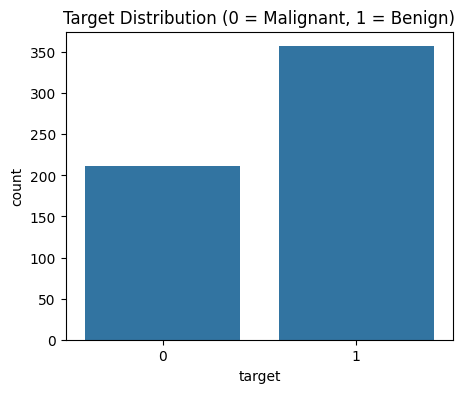

In [13]:
# Target distribution plot
plt.figure(figsize=(5,4))
sns.countplot(x='target', data=df)
plt.title("Target Distribution (0 = Malignant, 1 = Benign)")
plt.show()

#### Correlation Matrix & Heatmap

- Measure linear relationships between features and with the target.
- Detect highly correlated features, which may cause multicollinearity in models (e.g., logistic regression).
- Identify top predictive features related to cancer diagnosis.

In [14]:
# Correlation matrix
correlation_matrix = df.corr()

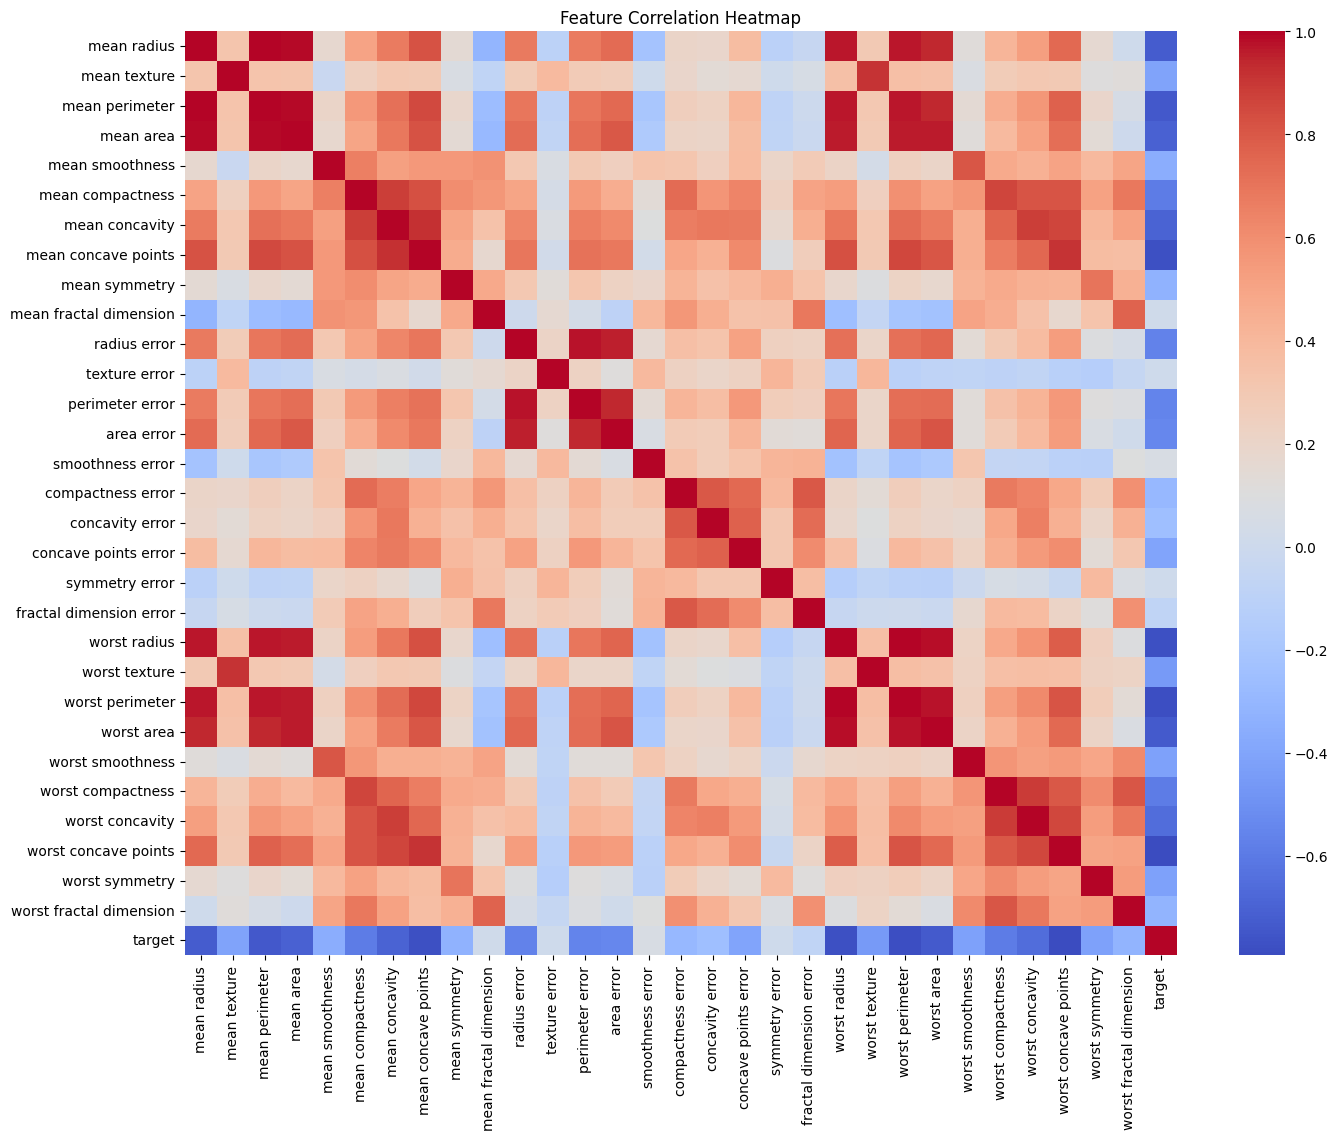

In [15]:
# Correlation heatmap
plt.figure(figsize=(16,12))
sns.heatmap(correlation_matrix, cmap='coolwarm', annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()

#### Co-relations

#### Feature Histograms

- Show distribution of each feature (normal, skewed, multimodal).
- Detect outliers and feature scaling requirements.
- Identify potential transformations (e.g., log transformation for skewed data).

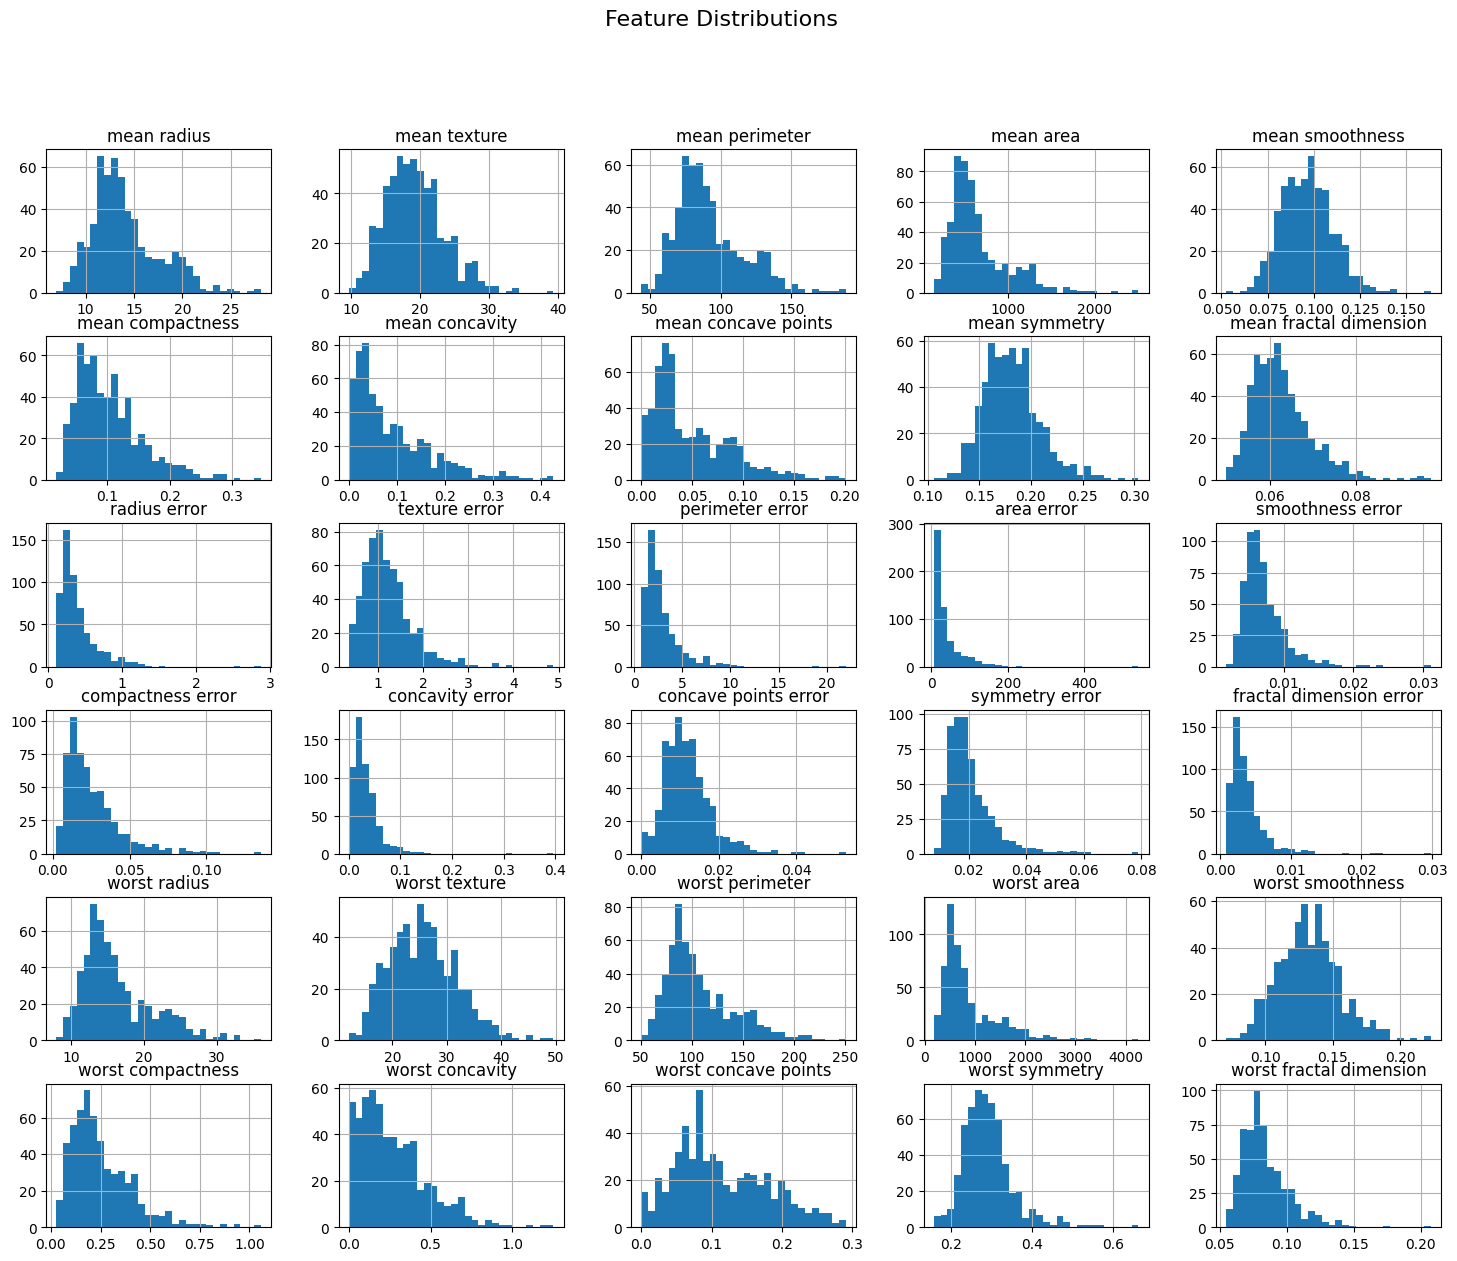

In [16]:
# Histogram of all features
df.drop('target', axis=1).hist(figsize=(18, 14), bins=30)
plt.suptitle("Feature Distributions", fontsize=16)
plt.show()

#### Boxplots (Selected Features or All Features)

- Detect outliers and extreme values visually.
- Compare value spread across different features.
- Identify if feature scaling or outlier handling (e.g., capping or transformation) is required before modeling.

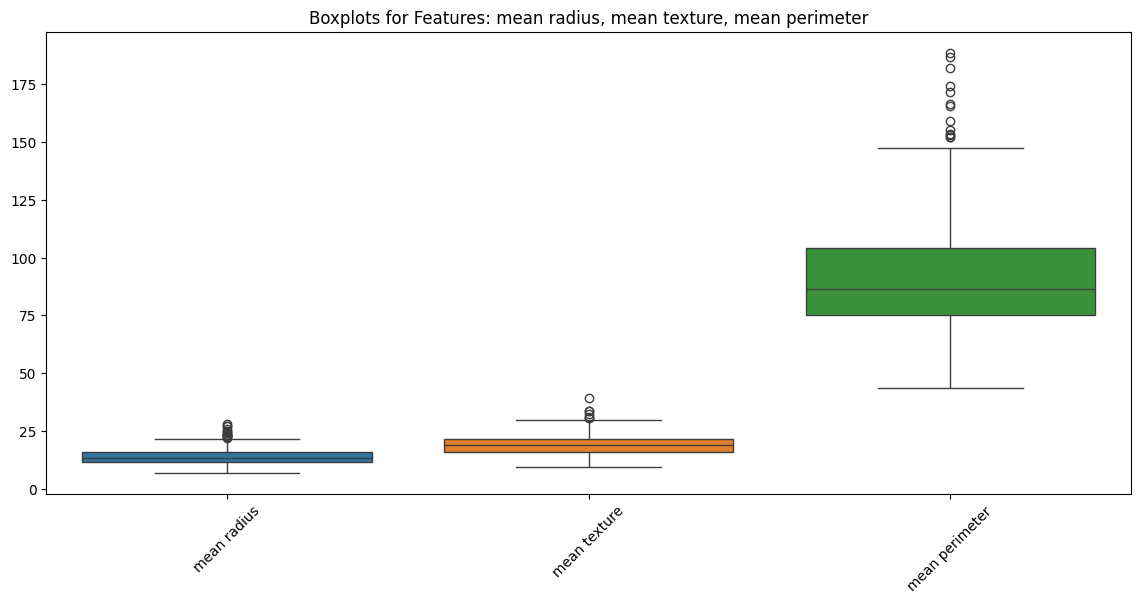

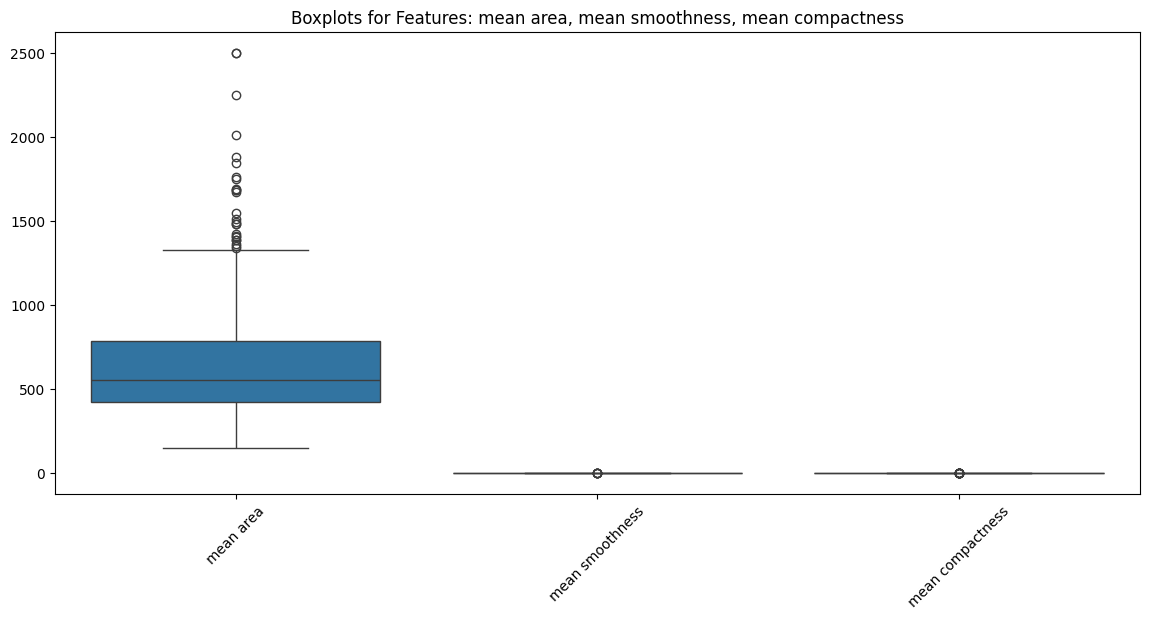

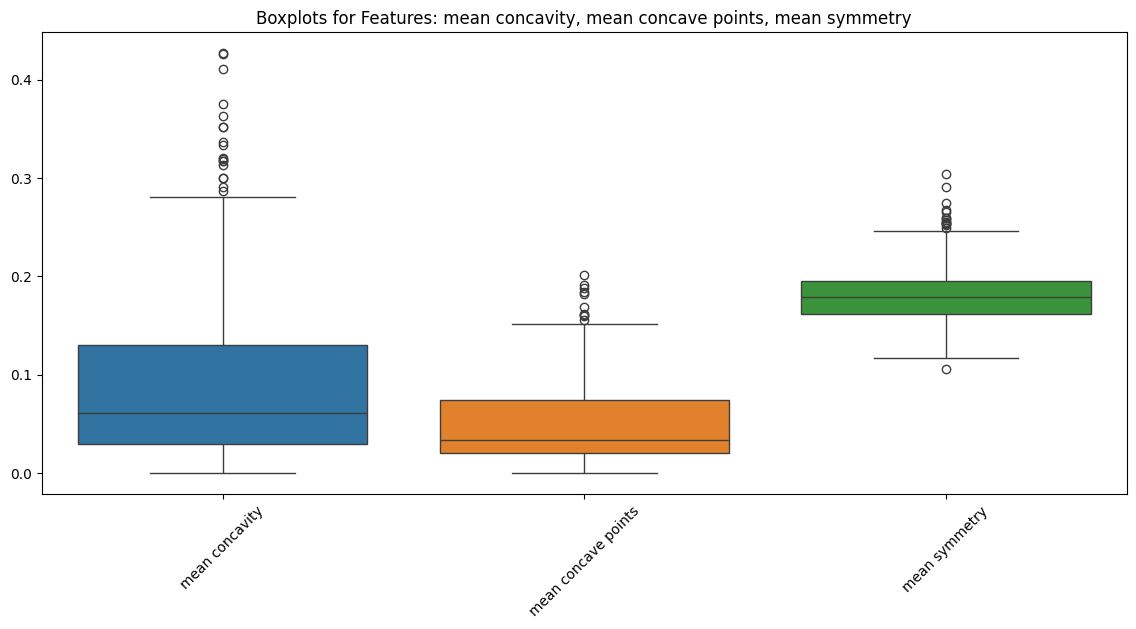

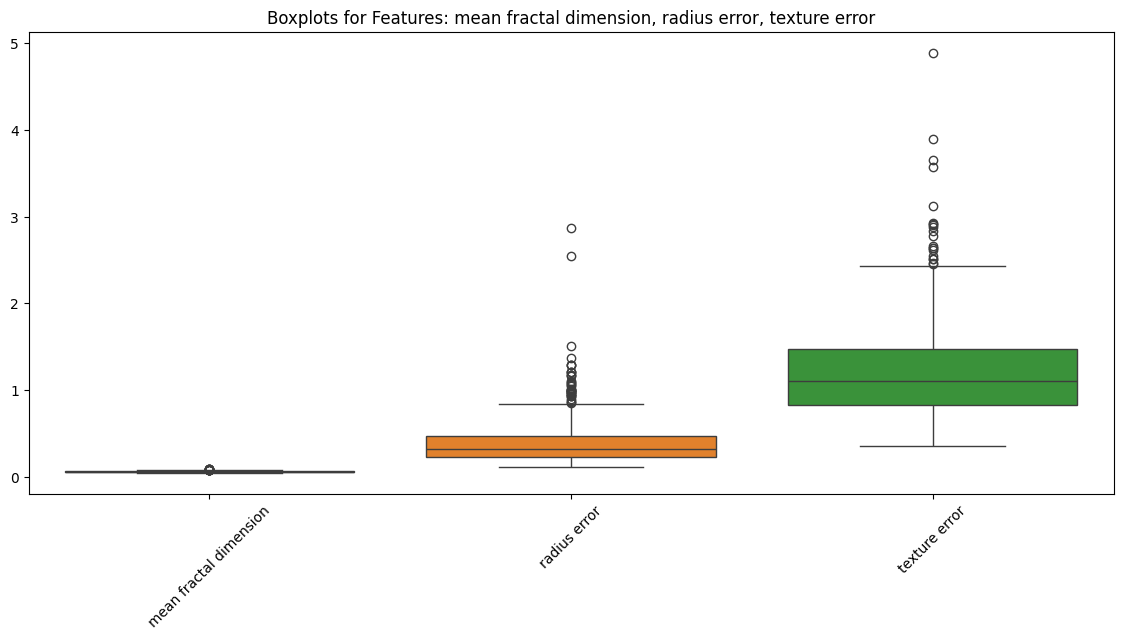

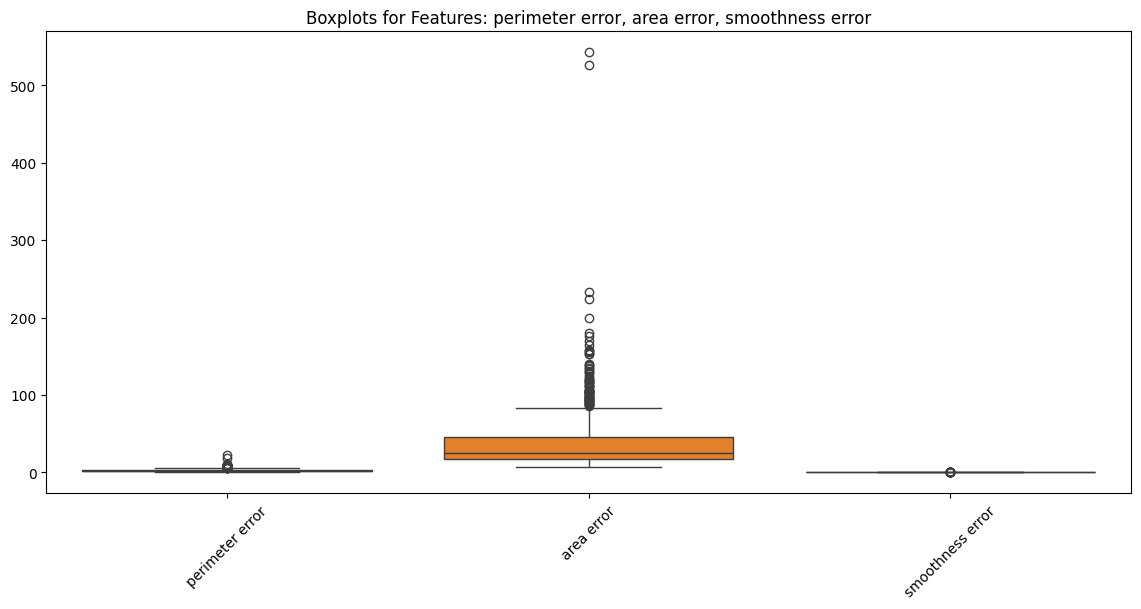

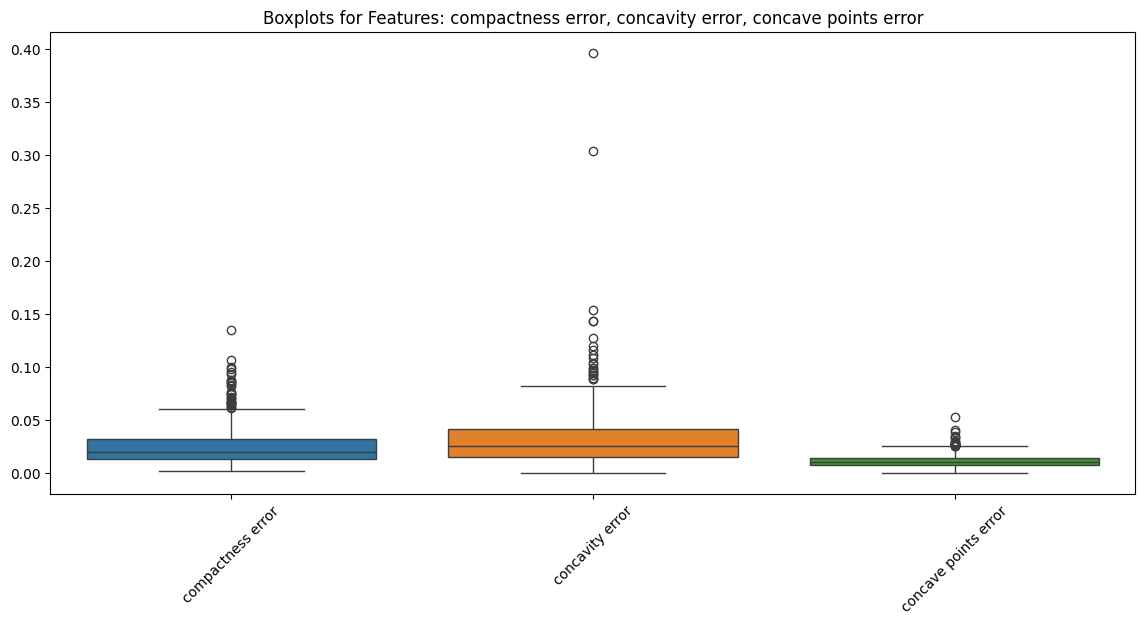

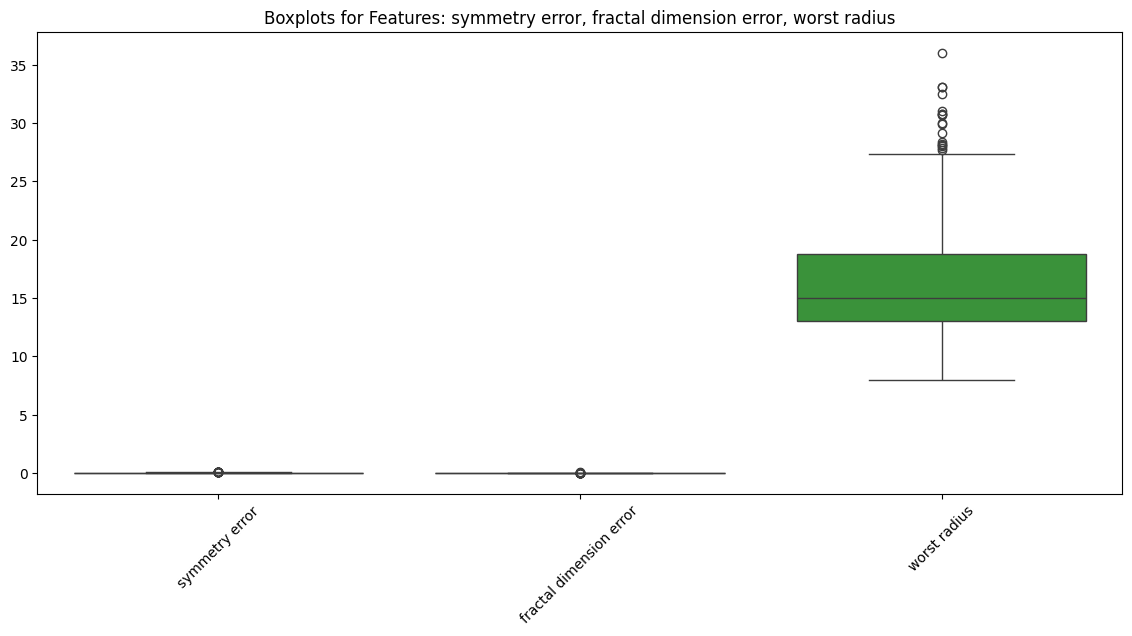

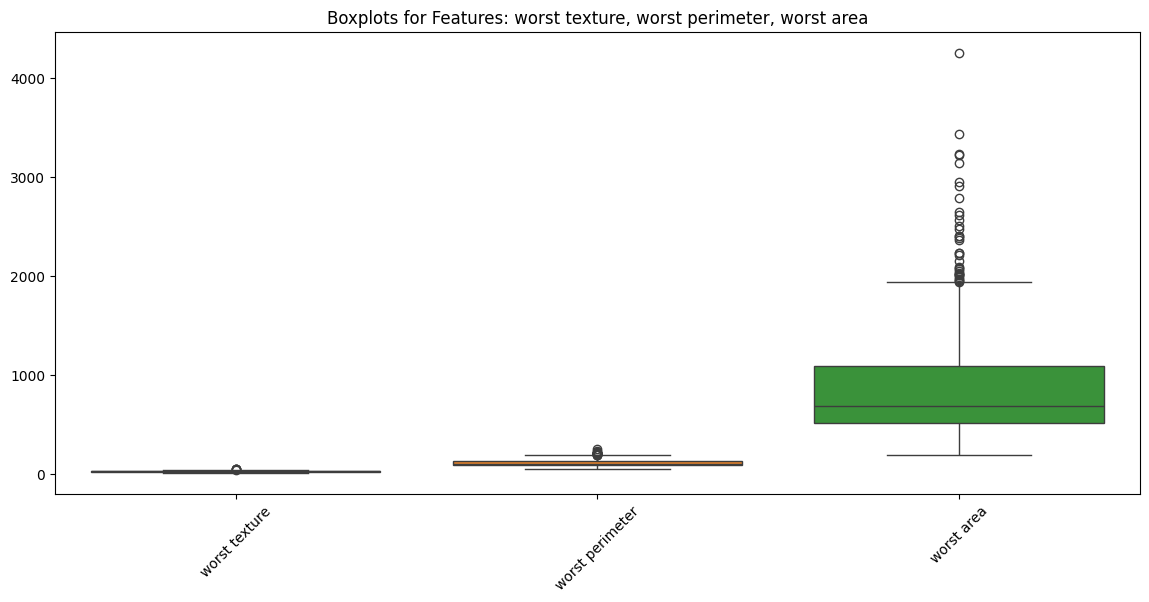

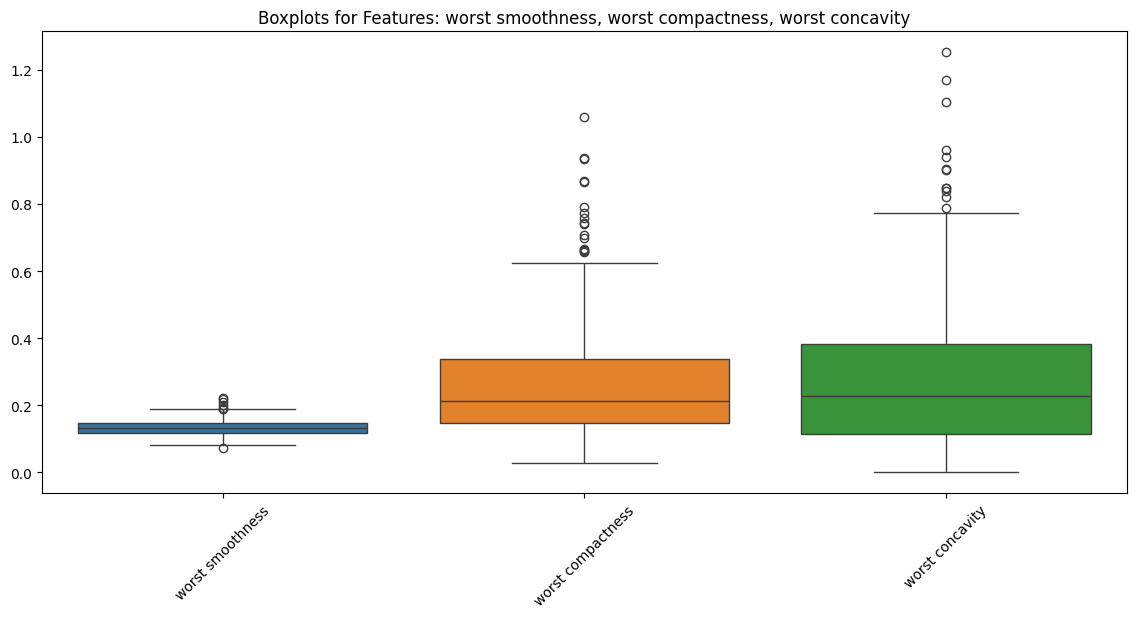

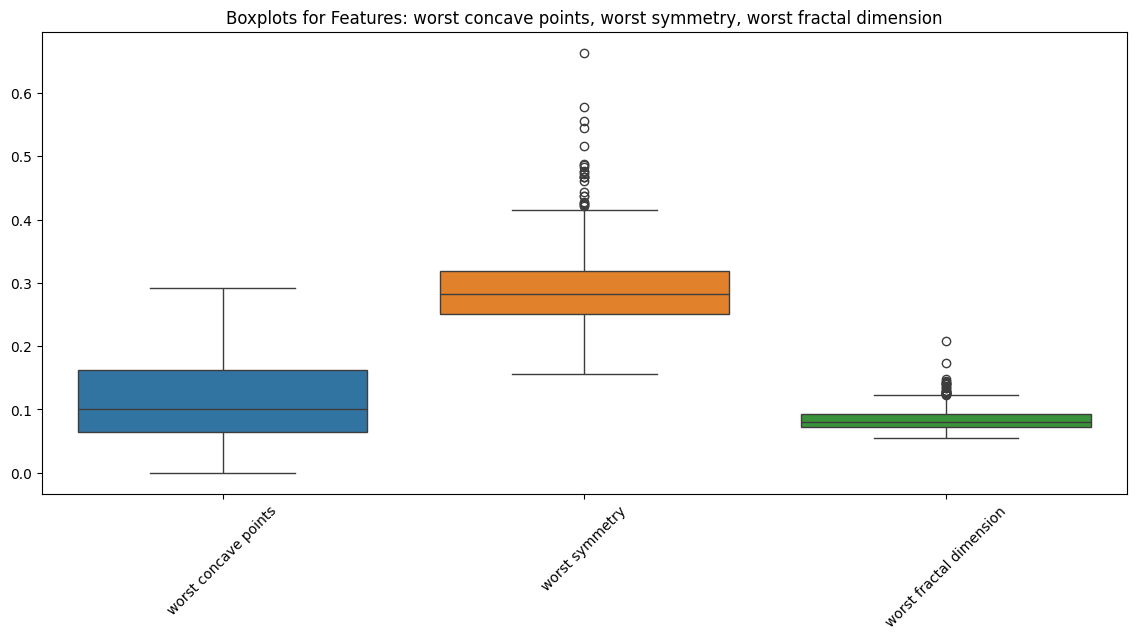

In [17]:
# Boxplot for detecting outliers in selected features
# Generate boxplots for all features (excluding target), similar to histograms but in batches for readability

features = df.drop('target', axis=1).columns
num_features = len(features)
cols_per_plot = 3  # number of features to show in each boxplot group

# Split features into chunks of size cols_per_plot
feature_chunks = [features[i:i+cols_per_plot] for i in range(0, num_features, cols_per_plot)]

for chunk in feature_chunks:
    plt.figure(figsize=(14,6))
    sns.boxplot(data=df[chunk])
    plt.title(f"Boxplots for Features: {', '.join(chunk)}")
    plt.xticks(rotation=45)
    plt.show()

#### Pairplots 
- Visualize relationships between top correlated features and target variable.
- Helps see if features separate the classes well (good for selecting features for classifiers).

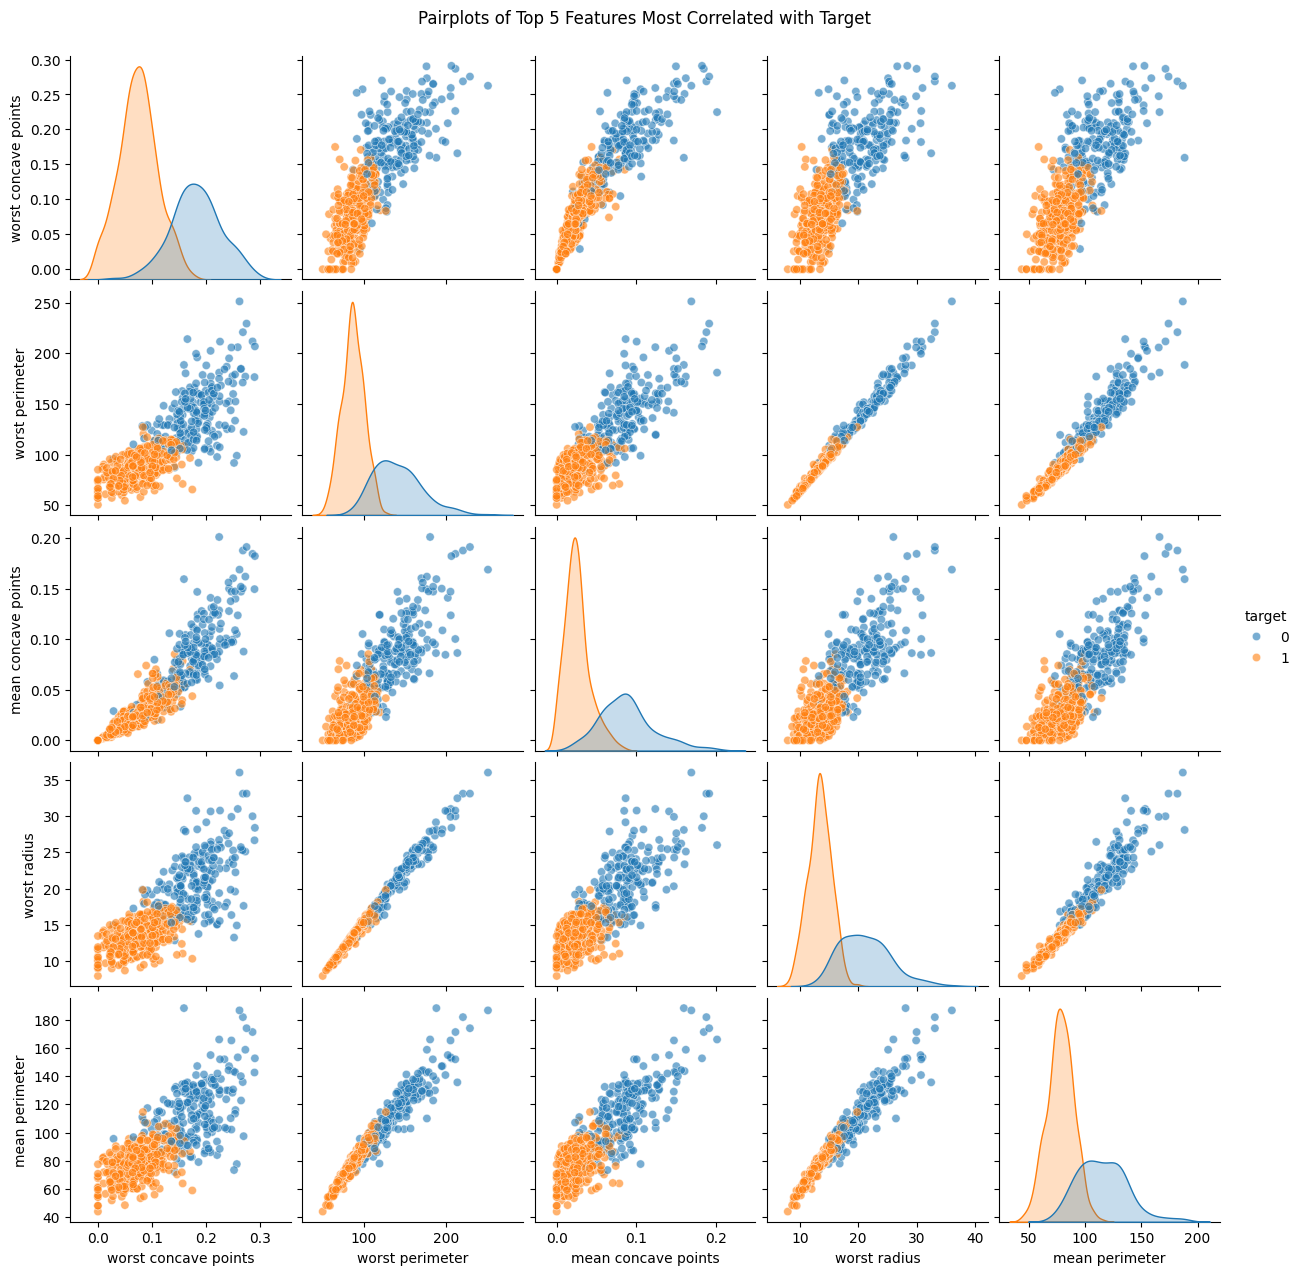

In [18]:
# Pairplots for top 5 features most correlated with the target variable

# Get top 5 features correlated with target (excluding target itself)
top_features = df.corr()['target'].abs().sort_values(ascending=False).index[1:6]

# Create a new dataframe with only these features and target
pairplot_df = df[top_features.tolist() + ['target']]

# Pairplot with hue based on target class
sns.pairplot(pairplot_df, hue='target', diag_kind='kde', plot_kws={'alpha':0.6})
plt.suptitle("Pairplots of Top 5 Features Most Correlated with Target", y=1.02)
plt.show()

- **Visualize Feature Relationships**
    - Pairplots show scatter plots between every pair of selected features, helping to visually inspect how features relate to each other.

- **Class Separation Check**
    - By coloring points based on the target variable (Benign vs. Malignant), we can quickly see if the classes are well separated in certain feature combinations.
    - This gives an early idea of how well a classifier may perform using these features.

- **Detect Patterns and Clusters**
    - Identifies natural groupings or clusters in the data, even before modeling.
    - Helps spot whether multiple cancer types may form distinguishable patterns.

- **Non-linear Relationships**
    - Shows relationships that may not be visible in correlation heatmaps, which only capture linear relationships.

- **Outlier Detection**
    - Outliers stand out as points far from the main data cloud in the scatter plots.

#### Check for constant or zero-variance features (low-information predictors)

Low-variance features are those that show little to no change across the dataset. These features often **do not add predictive power** and may even harm the model. Here's why:

`No Discriminative Power`
- If a feature has **very low variance**, most of its values are the same (e.g., 99% of entries are "1").
- Such a feature does **not help distinguish between classes** or predict the target.
- **Example:** A column like `is_human` with value `1` for almost all rows adds no predictive value.

`Adds Noise to the Model`
- Low-variance features may add **irrelevant signals**.
- Can lead to **overfitting** or **longer training times** without improving accuracy.

`Affects Distance-Based Algorithms`
- Models like **KNN**, **SVM (RBF kernel)**, and **clustering algorithms** use distance metrics.
- Features with almost no variability contribute **nothing meaningful** to the distance computation but still **add dimensionality**.

`Increases Dimensionality (Curse of Dimensionality)`
- Each unnecessary feature **increases the number of dimensions** without benefit.
- Removing low-variance features **simplifies the model** and improves **interpretability**.

`Best Practice`
- Identify features with **variance ≤ a small threshold** (e.g., `1e-5`) and consider dropping them.
- If a feature is **constant**, it can be safely removed without losing information.


In [19]:
# Check for constant or zero-variance features in the dataset

# Calculate variance for each feature (excluding target)
variance = df.drop('target', axis=1).var()

# Identify zero or near-zero variance features (threshold = 1e-5)
low_variance_features = variance[variance <= 1e-3]

# Prepare results DataFrame
low_variance_df = pd.DataFrame({
    'Feature': low_variance_features.index,
    'Variance': low_variance_features.values
})

low_variance_df

,Feature,Variance
0,mean smoothness,0.000198
1,mean symmetry,0.000752
2,mean fractal dimension,0.000050
3,smoothness error,0.000009
4,compactness error,0.000321
5,concavity error,0.000911
6,concave points error,0.000038
7,symmetry error,0.000068
8,fractal dimension error,0.000007
9,worst smoothness,0.000521


#### Distribution Analysis by Target Class

- To **understand how each feature differs** between target classes (e.g., **Malignant vs. Benign tumors**).
- Helps identify **discriminative features** that separate classes well.
- Guides **feature selection** and **model choice** in classification problems.



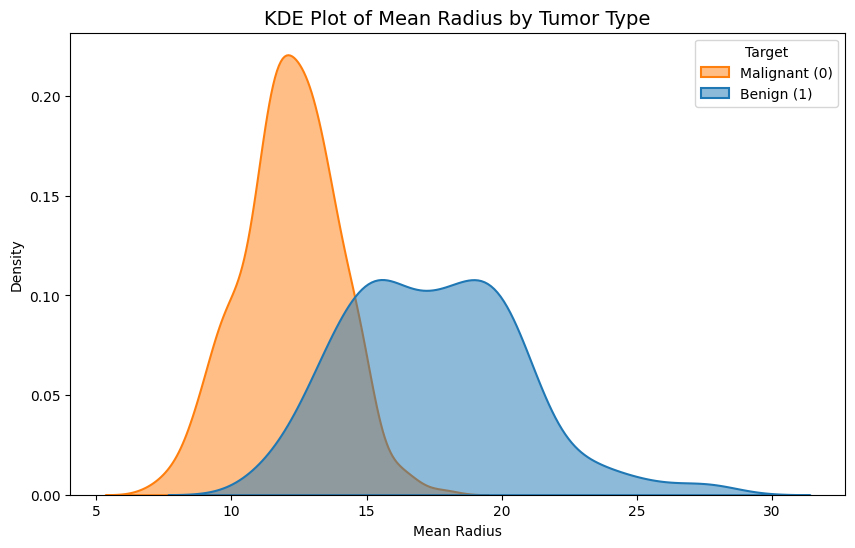

In [20]:
# KDE plot for a single feature
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='mean radius', hue='target', fill=True, 
            common_norm=False, alpha=0.5, linewidth=1.5)
plt.title("KDE Plot of Mean Radius by Tumor Type", fontsize=14)
plt.xlabel("Mean Radius")
plt.ylabel("Density")
plt.legend(title='Target', labels=['Malignant (0)', 'Benign (1)'])
plt.show()

- Two Distinct Density Curves:
    - Orange Curve (Malignant): Mostly centered around 11–15 units of mean radius.
    - Blue Curve (Benign): Mostly centered around 15–20 units of mean radius.

- Class Separation:
    - There is a visible gap between the peaks of both curves.
    - Indicates that “Mean Radius” is a discriminative feature, helping to distinguish malignant from benign tumors.

- Overlap Region (~13–15):
    - Both tumor types show similar values in this small range.
    - This overlap could lead to some classification uncertainty in this interval.

- Distribution Shape:
    - Malignant tumors: Skewed slightly left (smaller mean radius values dominate).
    - Benign tumors: Skewed slightly right (larger mean radius values).
    - Suggests benign tumors generally have larger mean radius compared to malignant ones.

- Higher mean radius values are more likely to correspond to benign tumors.

- Lower mean radius values are more likely to correspond to malignant tumors.

- This feature alone provides good predictive power, but due to overlap, using it with other features will improve classification accuracy.

#### Top 10 Feature KDE Plots Grid (2x5 layout)

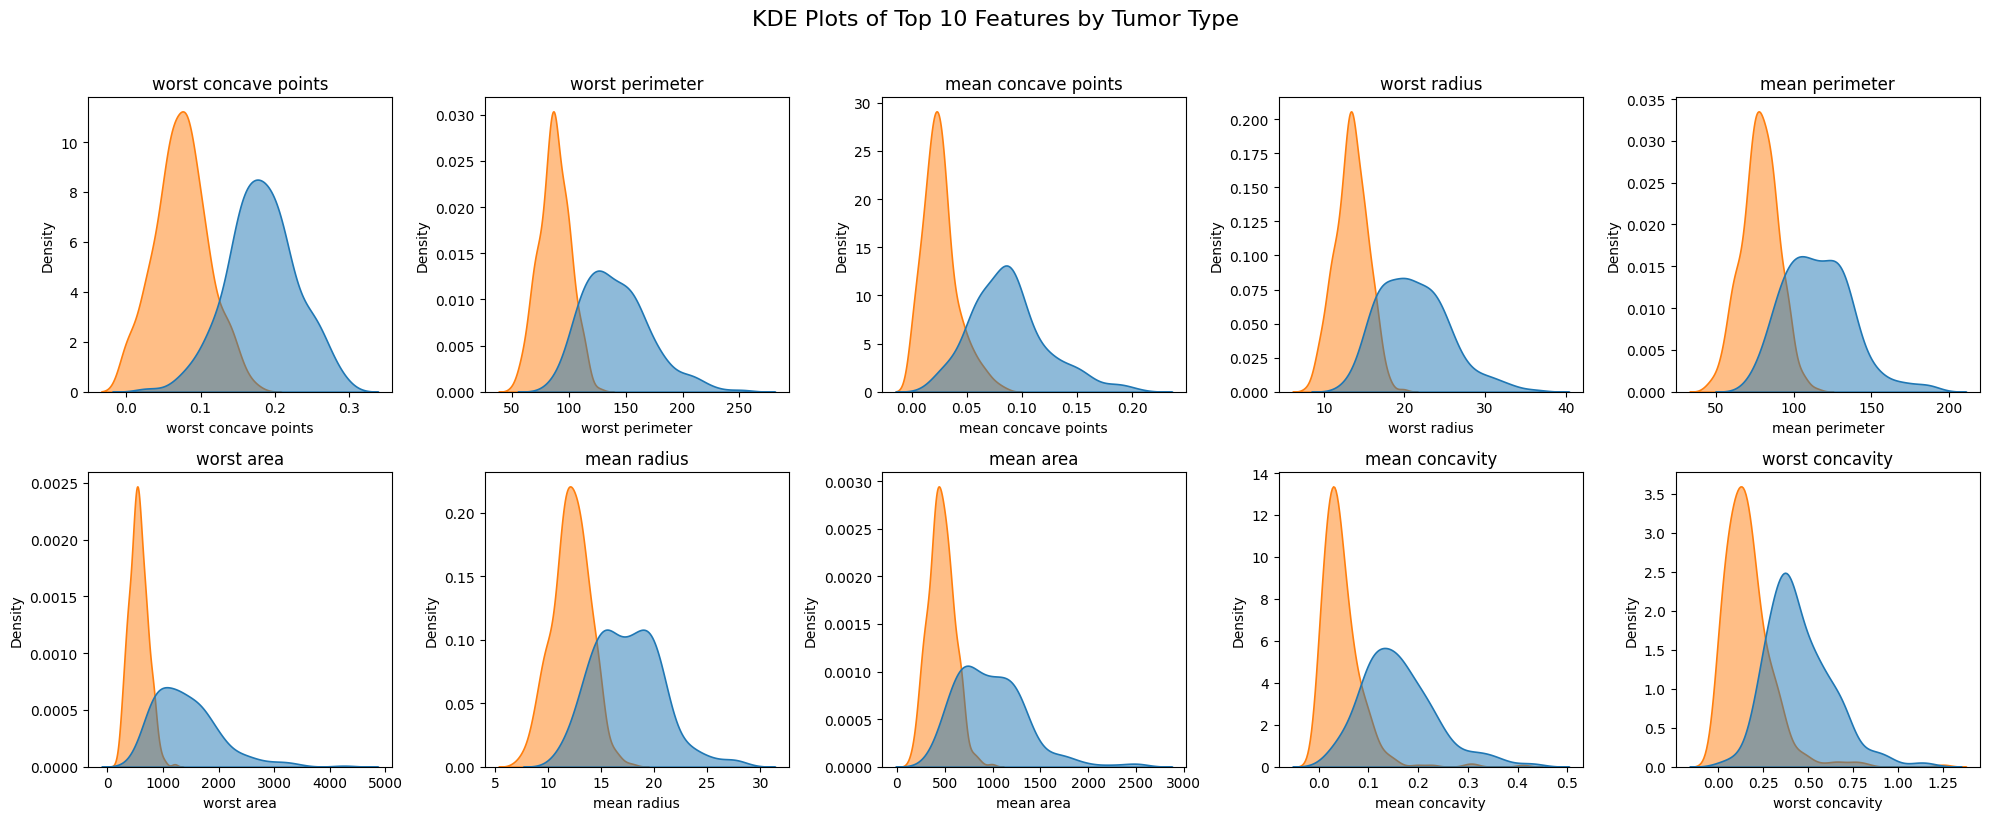

In [21]:
# Find top 10 features most correlated with target
top_10_features = df.corr()['target'].abs().sort_values(ascending=False).index[1:11]

# Create subplots
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

# Loop through top features and plot KDEs
for i, feature in enumerate(top_10_features):
    sns.kdeplot(data=df, x=feature, hue='target', fill=True, 
                common_norm=False, alpha=0.5, linewidth=1.2, ax=axes[i])
    axes[i].set_title(f"{feature}", fontsize=12)
    axes[i].legend([],[], frameon=False)  # Remove legend for clarity

# Add a main title and adjust layout
fig.suptitle("KDE Plots of Top 10 Features by Tumor Type", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

#### Feature Importance Ranking
- Purpose: Identify which features are most influential in distinguishing cancer types.

    - Calculate mutual information or ANOVA F-scores for features vs. target.

    - Helps in feature selection before modeling.

In [22]:
# mutual info
# Measures the **amount of information** a feature contributes to predicting the target.
# captures **non-linear relationships**, unlike correlation.
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

X = df.drop('target', axis=1)
y = df['target']

mi_scores = mutual_info_classif(X, y, random_state=42)
mi_df = pd.DataFrame({'Feature': X.columns, 'MI Score': mi_scores})
mi_df = mi_df.sort_values(by='MI Score', ascending=False)
mi_df

,Feature,MI Score
22,worst perimeter,0.471842
23,worst area,0.464313
20,worst radius,0.451230
7,mean concave points,0.438806
27,worst concave points,0.436255
2,mean perimeter,0.402361
6,mean concavity,0.375447
0,mean radius,0.362276
3,mean area,0.360023
13,area error,0.340759


**Key Insights from MI Scores**
```text
Top Influential Features:
    worst perimeter (0.472)
    worst area (0.464)
    worst radius (0.451)
    mean concave points (0.439)
    worst concave points (0.436)

→ These features carry high information gain about whether a tumor is malignant or benign.
```

```text
Medium-Influence Features:

    mean concavity, mean radius, mean area, area error, etc.
    Still relevant, can be included in early models.
```

```text
Low-Influence Features:

texture error (0.0), mean fractal dimension (0.0059), symmetry error (0.0142).
Likely contribute very little to prediction → candidates for removal or dimensionality reduction.
```


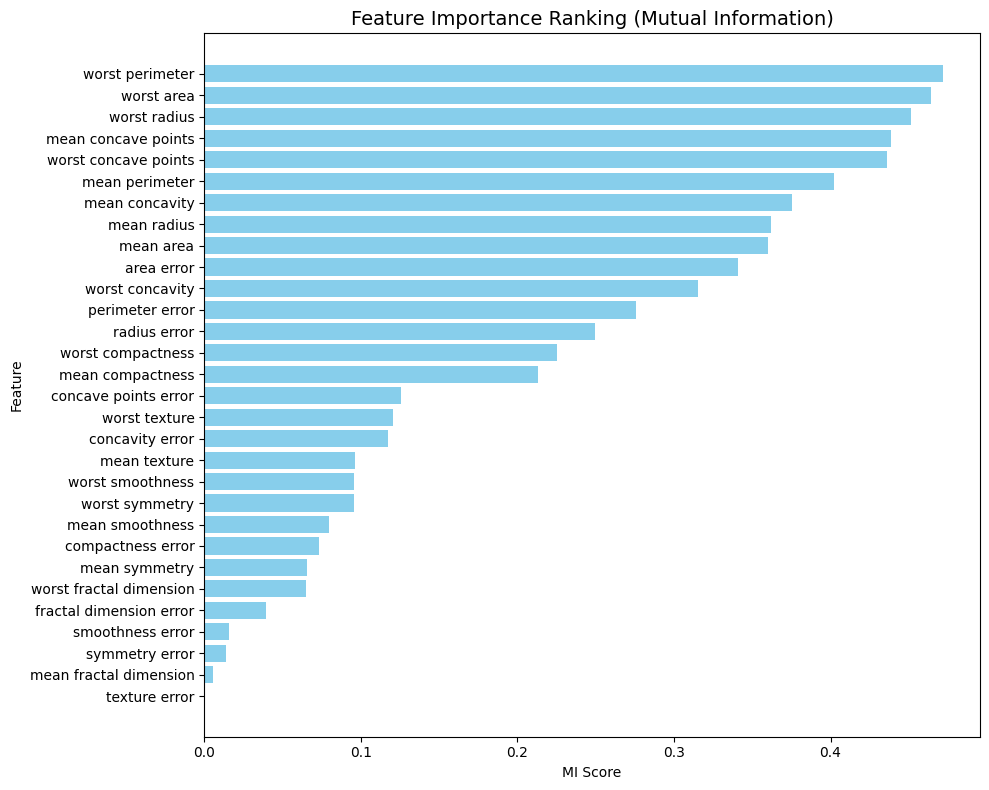

In [23]:
mi_df_sorted = mi_df.sort_values(by='MI Score', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(mi_df_sorted['Feature'], mi_df_sorted['MI Score'], color='skyblue')
plt.title("Feature Importance Ranking (Mutual Information)", fontsize=14)
plt.xlabel("MI Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

#### ANOVA F-Score
- Evaluates whether mean differences between target classes are significant for each feature.
- Works well for numeric features vs. categorical target.

In [24]:
from sklearn.feature_selection import f_classif

f_scores, p_values = f_classif(X, y)
anova_df = pd.DataFrame({'Feature': X.columns, 'F-Score': f_scores, 'p-value': p_values})
anova_df = anova_df.sort_values(by='F-Score', ascending=False)
anova_df


,Feature,F-Score,p-value
27,worst concave points,964.385393,1.969100e-124
22,worst perimeter,897.944219,5.771397e-119
7,mean concave points,861.676020,7.101150e-116
20,worst radius,860.781707,8.482292e-116
2,mean perimeter,697.235272,8.436251e-101
23,worst area,661.600206,2.828848e-97
0,mean radius,646.981021,8.465941e-96
3,mean area,573.060747,4.734564e-88
6,mean concavity,533.793126,9.966556e-84
26,worst concavity,436.691939,2.464664e-72


Top Discriminative Features (Very High F-scores, p ≈ 0)

    worst concave points (964)
    worst perimeter (898)
    mean concave points (862)
    worst radius (861)
    These features strongly differentiate between tumor types.

Moderate Importance Features

    mean compactness, radius error, area error, etc.
    Still significant (very low p-values) and contribute to classification.

Low or Non-significant Features (High p-values > 0.05)

    fractal dimension error (p=0.063)
    smoothness error (p=0.11)
    mean fractal dimension (p=0.76)
    texture error (p=0.84)
    symmetry error (p=0.88)

    These features likely do not add predictive power and can be dropped or deprioritized.

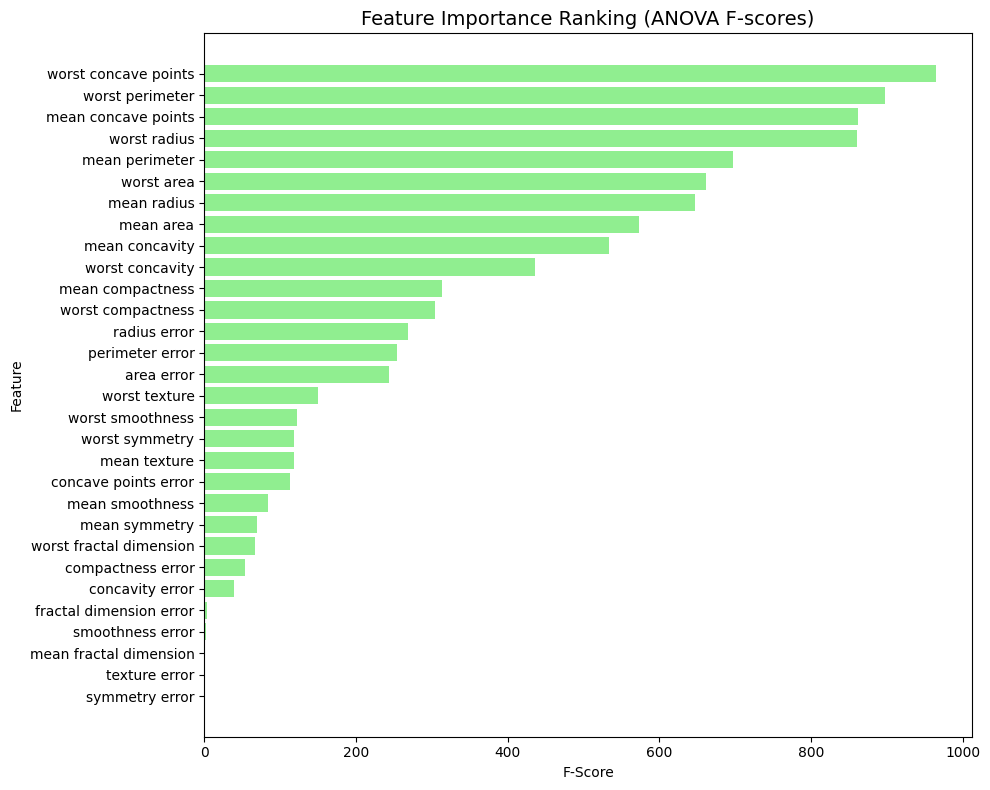

In [25]:
anova_df_sorted = anova_df.sort_values(by='F-Score', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(anova_df_sorted['Feature'], anova_df_sorted['F-Score'], color='lightgreen')
plt.title("Feature Importance Ranking (ANOVA F-scores)", fontsize=14)
plt.xlabel("F-Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

#### Multicollinearity Check
- Purpose: Identify highly correlated features that could lead to redundancy or model instability.

- Correlation Heatmap → Identify features with high correlation (e.g., > 0.9).
- Variance Inflation Factor (VIF) → Quantify multicollinearity.
Action: Drop or combine correlated features to avoid overfitting.


- VIF > 10 → High multicollinearity (feature is redundant).
- VIF > 5 → Moderate multicollinearity (may consider dropping or combining).

In [28]:
#pip install statsmodels

In [26]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

X = df.drop('target', axis=1)

vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

vif_data.sort_values(by='VIF', ascending=False)

,Feature,VIF
0,mean radius,63306.172036
2,mean perimeter,58123.586079
20,worst radius,9674.742602
22,worst perimeter,4487.781270
3,mean area,1287.262339
23,worst area,1138.759252
9,mean fractal dimension,629.679874
29,worst fractal dimension,423.396723
4,mean smoothness,393.398166
24,worst smoothness,375.597155


This is common in the Breast Cancer dataset, where many features are derived (e.g., mean perimeter ≈ function of mean radius & mean area).

#### Why can a model still perform well despite high VIF (multicollinearity)?

- **VIF (Variance Inflation Factor)** measures multicollinearity—how much a feature is linearly predictable from others. High VIF means strong correlation among features.
- **Model performance** (especially for prediction) can still be good even with high VIF, because:
  - Many machine learning models (like tree-based models, random forests, boosting) are robust to multicollinearity.
  - Even in linear models, if the correlated features are all predictive of the target, the model can still make accurate predictions, though individual feature coefficients may be unstable.
  - Multicollinearity mainly affects interpretability (hard to say which feature is most important), not always predictive power.
  - If the signal is strong and the model is validated properly (e.g., with cross-validation), high VIF does not necessarily harm accuracy.
- **Summary:**
  - High VIF is a concern for interpretation, not always for prediction.
  - If your goal is prediction and the model is validated, high VIF may not be a problem.
  - For interpretability, consider dimensionality reduction (PCA) or feature selection to address multicollinearity.

#### Use PCA or Dimensionality Reduction

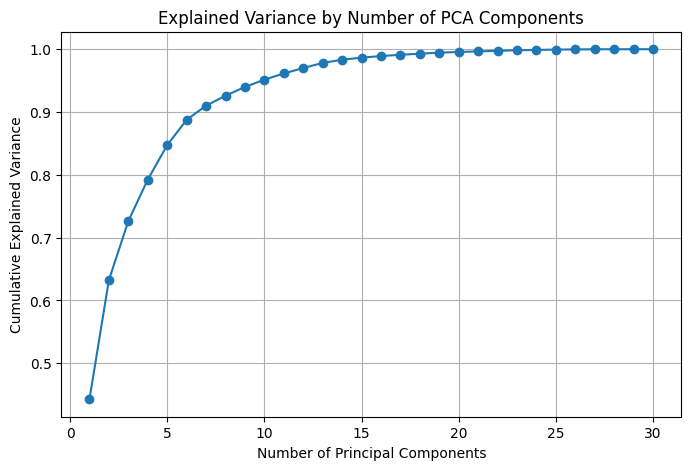

In [27]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd

# Separate features and target
X = df.drop('target', axis=1)
y = df['target']

# Standardize features (important for PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Explained variance ratio
explained_variance = pca.explained_variance_ratio_

# Plot cumulative variance
plt.figure(figsize=(8,5))
plt.plot(range(1, len(explained_variance)+1), explained_variance.cumsum(), marker='o')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by Number of PCA Components')
plt.grid(True)
plt.show()

In [28]:
pca = PCA(n_components=0.95)  # keep 95% variance
X_pca = pca.fit_transform(X_scaled)

print("Original features:", X.shape[1])
print("Reduced features:", X_pca.shape[1])

Original features: 30
Reduced features: 10


This means you reduced 30 correlated features → 10 independent PCs with minimal information loss.



-----
#### ML model build
---

In [29]:
from sklearn.model_selection import train_test_split

# Use PCA-transformed data (X_pca) or selected features from EDA
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [31]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)  # initial guess
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [32]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = knn.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9590643274853801

Confusion Matrix:
 [[ 57   7]
 [  0 107]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.89      0.94        64
           1       0.94      1.00      0.97       107

    accuracy                           0.96       171
   macro avg       0.97      0.95      0.96       171
weighted avg       0.96      0.96      0.96       171



---
#### Hyperparameter Tuning for KNN
---

In [33]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_neighbors': range(1, 21),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

Best Parameters: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'uniform'}
Best Score: 0.9724367088607595


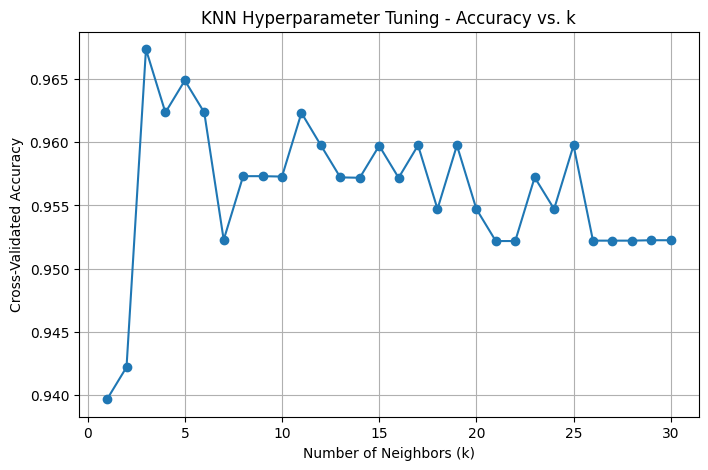

In [34]:
# Plot accuracy vs. k
from sklearn.model_selection import cross_val_score

k_range   = range(1, 31)
cv_scores = [cross_val_score(KNeighborsClassifier(n_neighbors=k), X_train, y_train, cv=5).mean() for k in k_range]

plt.figure(figsize=(8, 5))
plt.plot(k_range, cv_scores, marker='o')
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Cross-Validated Accuracy")
plt.title("KNN Hyperparameter Tuning - Accuracy vs. k")
plt.grid(True)
plt.show()

**Multiple metrics**

In [35]:
from sklearn.metrics import make_scorer, accuracy_score, f1_score, roc_auc_score

In [36]:
# Scale features
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [37]:
# Define parameter grid
param_grid = {
    'n_neighbors': range(1, 21),
    'weights': ['uniform', 'distance'],
    'metric':  ['euclidean', 'manhattan']
}

In [38]:
# Define multiple scorers
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'f1':       make_scorer(f1_score),
    'roc_auc':  make_scorer(roc_auc_score)
}

In [39]:
# Grid search with multiple metrics
grid_search = GridSearchCV(
    estimator =KNeighborsClassifier(),
    param_grid=param_grid,
    scoring   =scoring,
    refit     ='roc_auc',     # Model will refit using the metric you care about most
    cv        =5,
    n_jobs    =-1
)

In [40]:
grid_search.fit(X_scaled, y)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'metric': ['euclidean', 'manhattan'],
                         'n_neighbors': range(1, 21),
                         'weights': ['uniform', 'distance']},
             refit='roc_auc',
             scoring={'accuracy': make_scorer(accuracy_score, response_method='predict'),
                      'f1': make_scorer(f1_score, response_method='predict'),
                      'roc_auc': make_scorer(roc_auc_score, response_method='predict')})

In [41]:
# Results
results_df  = pd.DataFrame(grid_search.cv_results_)
best_params = grid_search.best_params_

print("Best Parameters (optimized for ROC_AUC):", best_params)

# Display top 5 results sorted by ROC_AUC
results_df[['param_n_neighbors', 'param_weights', 'param_metric',
            'mean_test_accuracy', 'mean_test_f1', 'mean_test_roc_auc']].sort_values(
    by='mean_test_roc_auc', ascending=False).head()

Best Parameters (optimized for ROC_AUC): {'metric': 'manhattan', 'n_neighbors': 4, 'weights': 'distance'}


,param_n_neighbors,param_weights,param_metric,mean_test_accuracy,mean_test_f1,mean_test_roc_auc
47,4,distance,manhattan,0.970113,0.976312,0.965636
14,8,uniform,euclidean,0.968343,0.974814,0.964283
46,4,uniform,manhattan,0.968343,0.974832,0.964227
12,7,uniform,euclidean,0.968359,0.975048,0.962338
15,8,distance,euclidean,0.968343,0.974994,0.962338


#### Final Model with Best Parameters

In [43]:
best_knn    = grid_search.best_estimator_
y_pred_best = best_knn.predict(X_test)

print("Final Accuracy:", accuracy_score(y_test, y_pred_best))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_best))

Final Accuracy: 1.0

Confusion Matrix:
 [[ 64   0]
 [  0 107]]


---
#### Compare Multiple ML Algorithms
- KNN is a good baseline, but you should benchmark against other models:
- Logistic Regression – interpretable linear classifier
- Decision Tree / Random Forest – handles non-linear relationships well
- Support Vector Machine (SVM) – effective for high-dimensional data
- Gradient Boosting (XGBoost, LightGBM) – often gives top accuracy
- ---

In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

In [45]:
# Define Models

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(kernel='rbf', probability=True, random_state=42),
    'XGBoost': XGBClassifier(eval_metric='logloss', random_state=42)
}

In [46]:
# Evaluate Models using Cross-Validation

results = {}
for name, model in models.items():
    acc     = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy').mean()
    f1      = cross_val_score(model, X_train, y_train, cv=5, scoring='f1').mean()
    roc_auc = cross_val_score(model, X_train, y_train, cv=5, scoring='roc_auc').mean()
    
    results[name] = {'Accuracy': acc, 'F1': f1, 'ROC-AUC': roc_auc}

In [47]:
# Convert to DataFrame for comparison
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values(by='ROC-AUC', ascending=False)
results_df

,Accuracy,F1,ROC-AUC
SVM,0.969810,0.976079,0.992910
Logistic Regression,0.979937,0.984196,0.990510
XGBoost,0.962405,0.969735,0.986329
Random Forest,0.972500,0.978098,0.985200
Decision Tree,0.924747,0.939416,0.922322


**Hyperparameter tuning with GridSearchCV for the top 2 models**

- Plot ROC curves for visual comparison of classifiers.
- Random Forest, XGBoost

In [48]:
# Define Hyperparameter Grids

rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

xgb_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1]
}

In [49]:
# GridSearchCV for Top 2 Models
rf_grid = GridSearchCV(
    estimator =RandomForestClassifier(random_state=42),
    param_grid=rf_param_grid,
    scoring   ='roc_auc',
    cv=5,
    n_jobs=-1
)
rf_grid.fit(X_train, y_train)

xgb_grid = GridSearchCV(
    estimator =XGBClassifier(eval_metric='logloss', random_state=42),
    param_grid=xgb_param_grid,
    scoring   ='roc_auc',
    cv=5,
    n_jobs=-1
)
xgb_grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraint...
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 5, 7], 'n_estimators': [50, 100, 200],
                         'subsample': [0.8, 1]},
             scoring='roc_auc')

In [64]:
print("Best RF Params:",  rf_grid.best_params_)
print("Best XGB Params:", xgb_grid.best_params_)

Best RF Params: {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
Best XGB Params: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1}


In [65]:
# Build Models with Best Params

rf_best  = rf_grid.best_estimator_
xgb_best = xgb_grid.best_estimator_
knn      = KNeighborsClassifier(n_neighbors=5)
lr       = LogisticRegression(max_iter=1000)

models = {
    'Logistic Regression': lr,
    'KNN': knn,
    'Random Forest (Tuned)': rf_best,
    'XGBoost (Tuned)': xgb_best
}

In [67]:
from sklearn.metrics import roc_curve, roc_auc_score

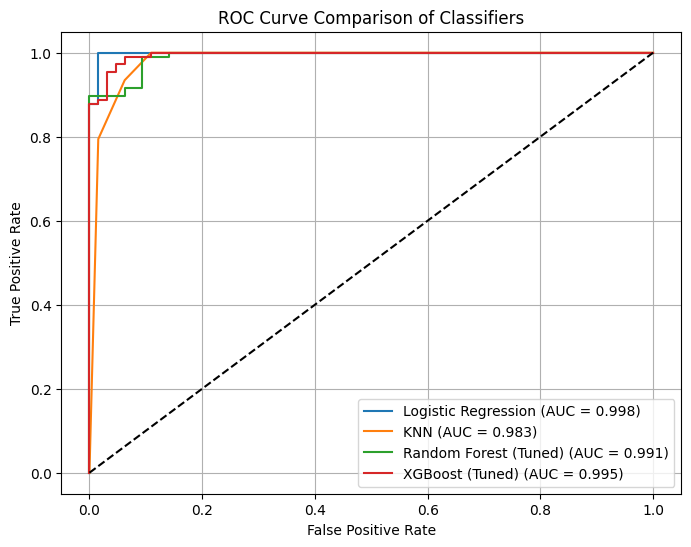

In [68]:
# Plot ROC Curves

plt.figure(figsize=(8, 6))

for name, model in models.items():
    model.fit(X_train, y_train)
    y_proba     = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc         = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve Comparison of Classifiers')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.show()

| Model                     | AUC Score | Interpretation                                                 |
| ------------------------- | --------- | -------------------------------------------------------------- |
| **Logistic Regression**   | **0.998** | Outstanding performance, nearly perfect separation of classes. |
| **XGBoost (Tuned)**       | **0.995** | Almost as good as logistic regression, robust predictions.     |
| **Random Forest (Tuned)** | **0.991** | Very high accuracy and discrimination power.                   |
| **KNN (Baseline)**        | **0.983** | Good performance, but slightly weaker than the others.         |


- Logistic Regression is a strong, simple baseline for this dataset.
- XGBoost and Random Forest are robust alternatives, especially if:
- Non-linear interactions are important
- Data complexity increases
- KNN is less reliable but still a reasonable baseline.

#### Understanding ROC curve

In [77]:
from sklearn.metrics import roc_curve, auc as sk_auc

In [78]:
# Helper function to plot ROC curve
def plot_roc(y_true, y_scores, ax, title):
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc     = sk_auc(fpr, tpr)  # Use sk_auc to avoid name conflict
    ax.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
    ax.plot([0, 1], [0, 1], 'k--')
    ax.set_title(title)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend()

In [81]:
# Generate larger synthetic dataset for better realism
np.random.seed(42)
n_samples = 200

scenarios = [
    ("Perfect classifier",
     np.array([1]*100 + [0]*100),
     np.concatenate([np.random.uniform(0.8, 1.0, 100),
                     np.random.uniform(0.0, 0.2, 100)])),

    ("Good classifier",
     np.array([1]*100 + [0]*100),
     np.concatenate([np.random.uniform(0.6, 0.95, 100),
                     np.random.uniform(0.05, 0.4, 100)])),

    ("Moderate classifier",
     np.array([1]*100 + [0]*100),
     np.concatenate([np.random.uniform(0.4, 0.9, 100),
                     np.random.uniform(0.1, 0.6, 100)])),

    ("Poor classifier",
     np.array([1]*100 + [0]*100),
     np.concatenate([np.random.uniform(0.3, 0.7, 100),
                     np.random.uniform(0.2, 0.8, 100)])),

    ("Random guessing",
     np.array([1]*100 + [0]*100),
     np.random.uniform(0.0, 1.0, 200)),

    ("Bad classifier (reversed)",
     np.array([1]*100 + [0]*100),
     np.concatenate([np.random.uniform(0.0, 0.3, 100),
                     np.random.uniform(0.7, 1.0, 100)])),

    ("High recall, low precision",
     np.array([1]*100 + [0]*100),
     np.concatenate([np.random.uniform(0.5, 1.0, 100),
                     np.random.uniform(0.3, 0.9, 100)])),

    ("High precision, low recall",
     np.array([1]*100 + [0]*100),
     np.concatenate([np.random.uniform(0.7, 1.0, 50),
                     np.random.uniform(0.0, 0.3, 50),
                     np.random.uniform(0.2, 0.6, 100)])),

    ("Overconfident wrong",
     np.array([1]*100 + [0]*100),
     np.concatenate([np.random.uniform(0.8, 1.0, 50),
                     np.random.uniform(0.6, 0.9, 50),
                     np.random.uniform(0.8, 1.0, 50),
                     np.random.uniform(0.6, 0.9, 50)])),

    ("Balanced classifier",
     np.array([1]*100 + [0]*100),
     np.concatenate([np.random.uniform(0.4, 0.8, 100),
                     np.random.uniform(0.2, 0.7, 100)])),
]


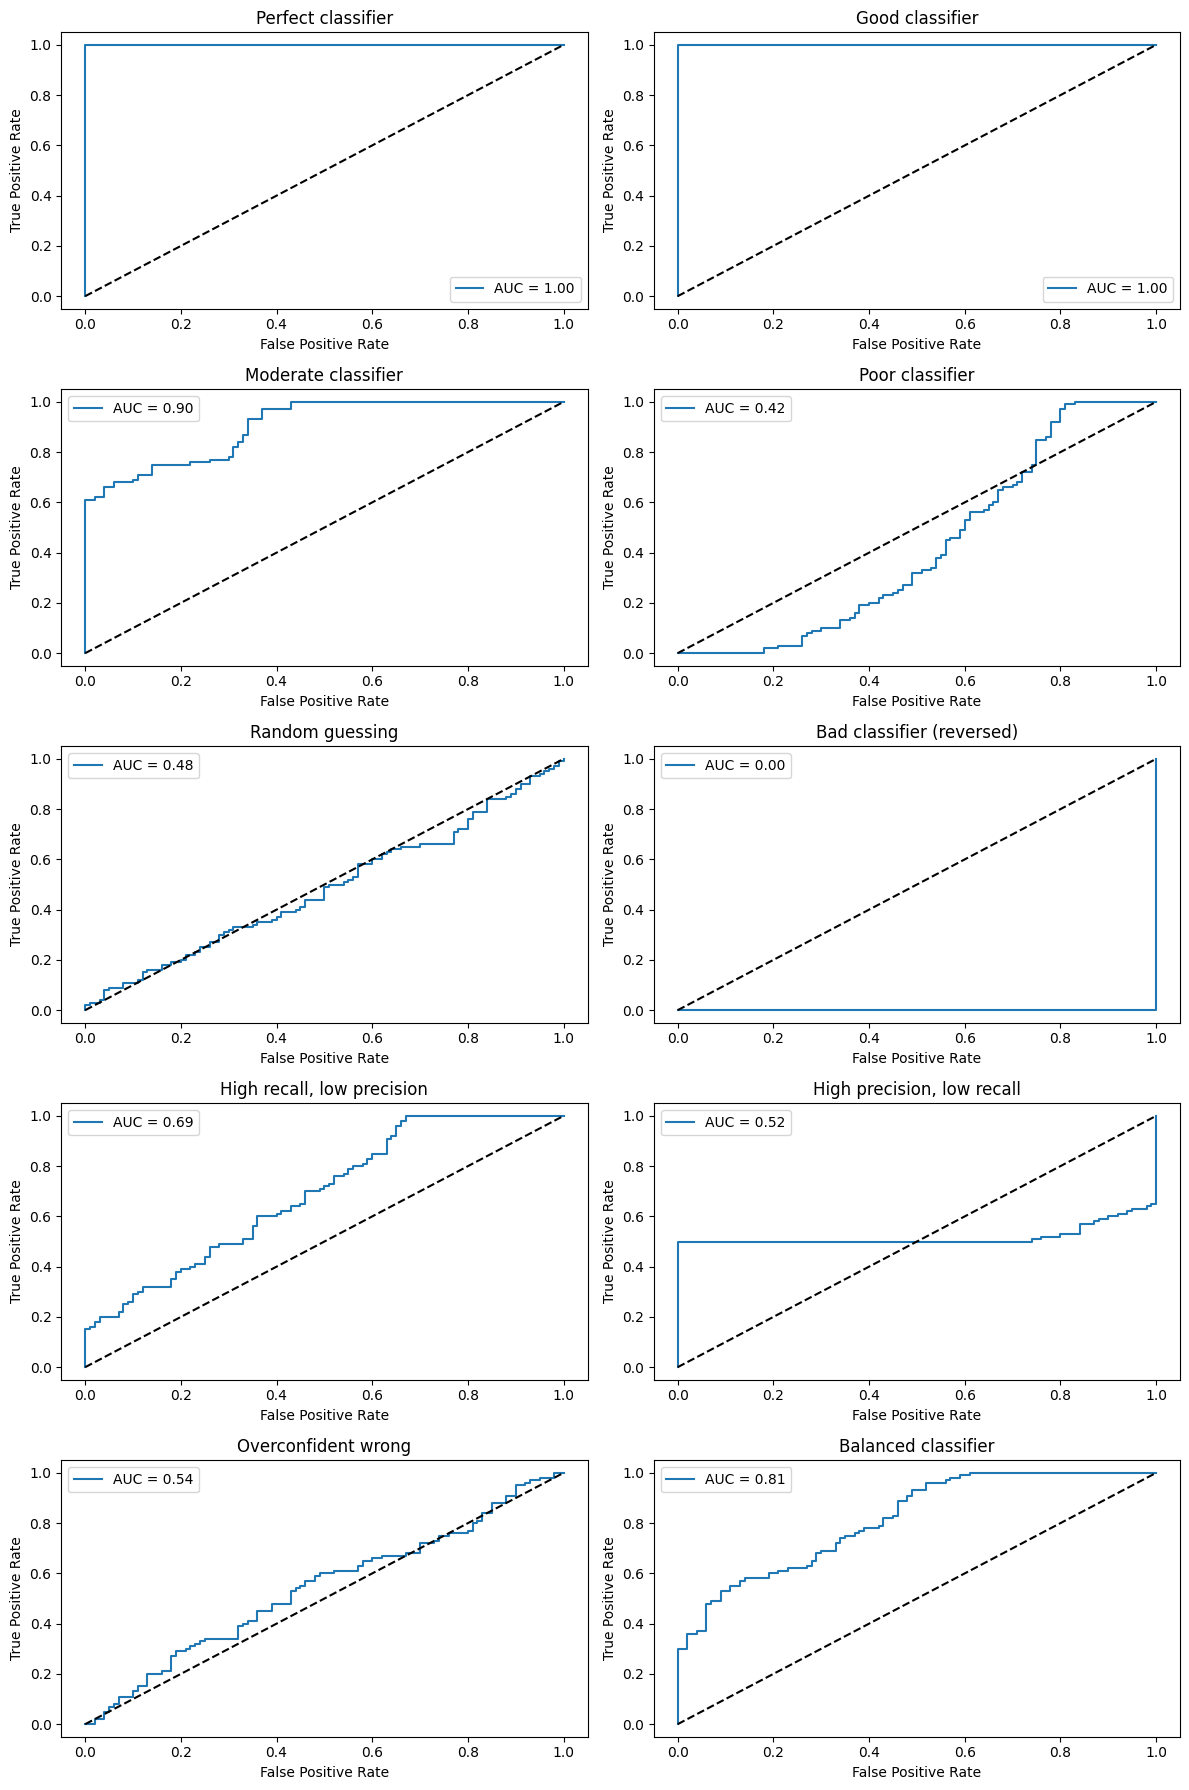

In [82]:
# Plotting 10 ROC curves
fig, axes = plt.subplots(5, 2, figsize=(12, 18))
axes = axes.ravel()

for idx, (title, y_true, y_scores) in enumerate(scenarios):
    plot_roc(y_true, y_scores, axes[idx], title)

plt.tight_layout()
plt.show()

----
#### Model Interpretation
---

4 selected models:

- rf_best → Tuned Random Forest
- xgb_best → Tuned XGBoost
- knn → KNN baseline
- lr → Logistic Regression baseline
- 
You can do feature importance, SHAP, and PDP for one or more models (usually for the best one, e.g., rf_best)

**1. Permutation Importance**

In [83]:
from sklearn.inspection import permutation_importance

In [84]:
model = rf_best
model.fit(X_train, y_train)

RandomForestClassifier(max_depth=5, min_samples_leaf=2, min_samples_split=5,
                       random_state=42)

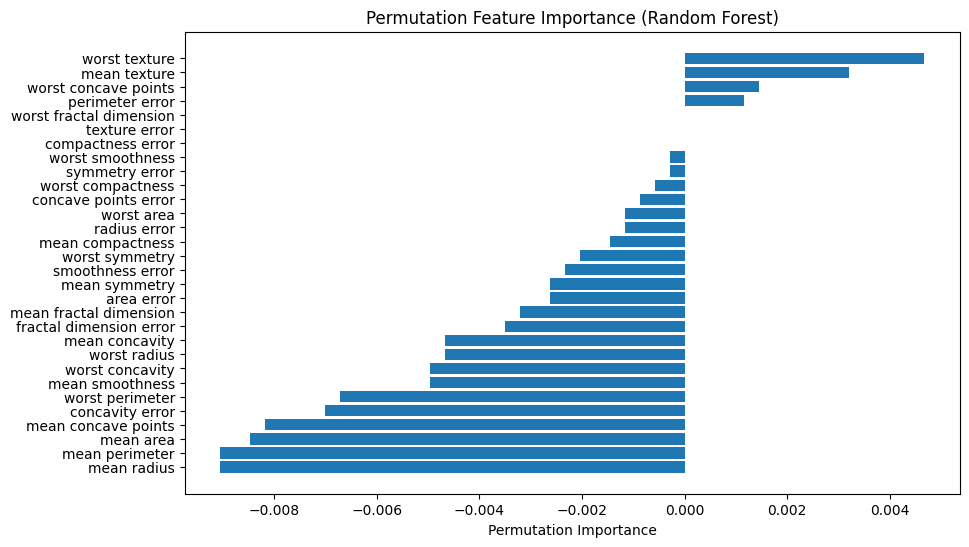

In [87]:
# Get feature names
feature_names = X.columns if hasattr(X, 'columns') else [f"Feature {i}" for i in range(X.shape[1])]

# Compute permutation importance
perm_importance = permutation_importance(model, X_test, y_test, n_repeats=20, random_state=42)
sorted_idx      = perm_importance.importances_mean.argsort()

plt.figure(figsize=(10,6))
plt.barh(range(len(sorted_idx)), perm_importance.importances_mean[sorted_idx])
plt.yticks(range(len(sorted_idx)), np.array(feature_names)[sorted_idx])
plt.xlabel("Permutation Importance")
plt.title("Permutation Feature Importance (Random Forest)")
plt.show()

- how much each feature contributes to the predictive performance of your tuned Random Forest (rf_best) model.

##### Understanding Positive and Negative Permutation Importance Scores

**What the Score Means**

- Permutation Importance measures how much the model's performance drops 
when a feature's values are randomly shuffled.  

**Formula:**  
$$
\Large \text{Importance} = \text{Base Model Score} - \text{Score after shuffling feature}
$$

- **Positive Value:**  Accuracy **drops** after shuffling → feature is **useful**.
- **Zero Value:**  Accuracy **unchanged** → feature has **no predictive value**.
- **Negative Value:** Accuracy **improves** after shuffling → feature may be **noisy or redundant**.

**what is shuffling**

Suppose you have a dataset:

| Sample | Feature A | Feature B | Target |
| ------ | --------- | --------- | ------ |
| 1      | 10        | 5         | Yes    |
| 2      | 20        | 7         | No     |
| 3      | 15        | 6         | Yes    |

 If we shuffle Feature A, we randomly rearrange its values:

| Sample | Feature A (shuffled) | Feature B | Target |
| ------ | -------------------- | --------- | ------ |
| 1      | 20                   | 5         | Yes    |
| 2      | 10                   | 7         | No     |
| 3      | 15                   | 6         | Yes    |

Now, the relationship between Feature A and Target is broken because the values no longer align with the correct samples.

We feed this shuffled dataset to the trained model and see if predictions get worse.

**Why we do this?**
- If accuracy drops a lot, the feature carried important predictive information.
- If accuracy doesn't change, the feature was not useful.
- If accuracy improves, the feature might have been misleading or redundant.

**Example Analogy**
- Imagine predicting house prices:
- You have:
    - Size of house (important feature)
    - House ID (useless feature)

- If you randomly shuffle the Size of house column:
- The relationship with price is destroyed.
    - Model predictions worsen.
    - Accuracy drops → the feature was important.

- If you shuffle House ID:
    - Predictions stay the same (it's useless).
    - No drop in accuracy.



In [88]:
# Store models in a dictionary
models = {
    "XGBoost": xgb_best,
    "KNN": knn,
    "Logistic Regression": lr
}

In [89]:
# Get feature names safely
feature_names = X.columns if hasattr(X, 'columns') else [f"Feature {i}" for i in range(X.shape[1])]

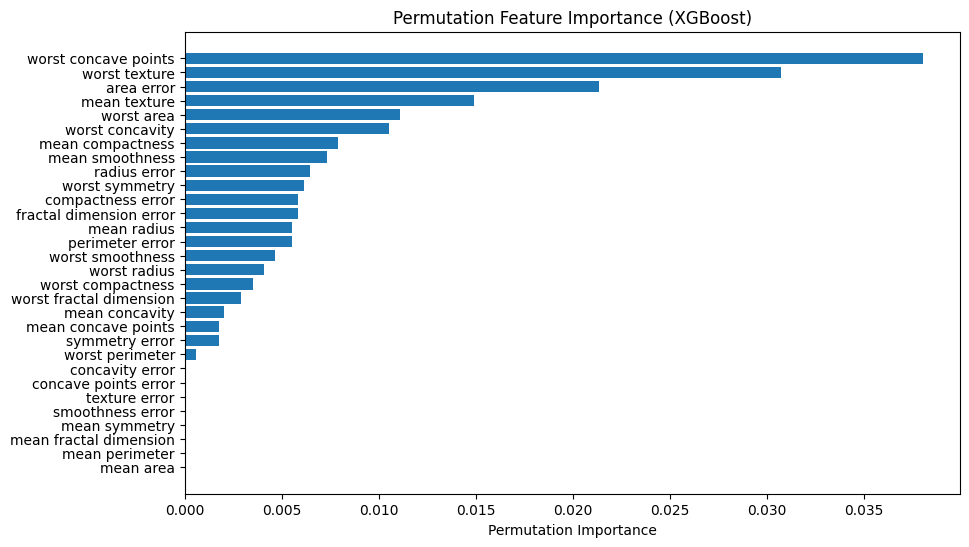

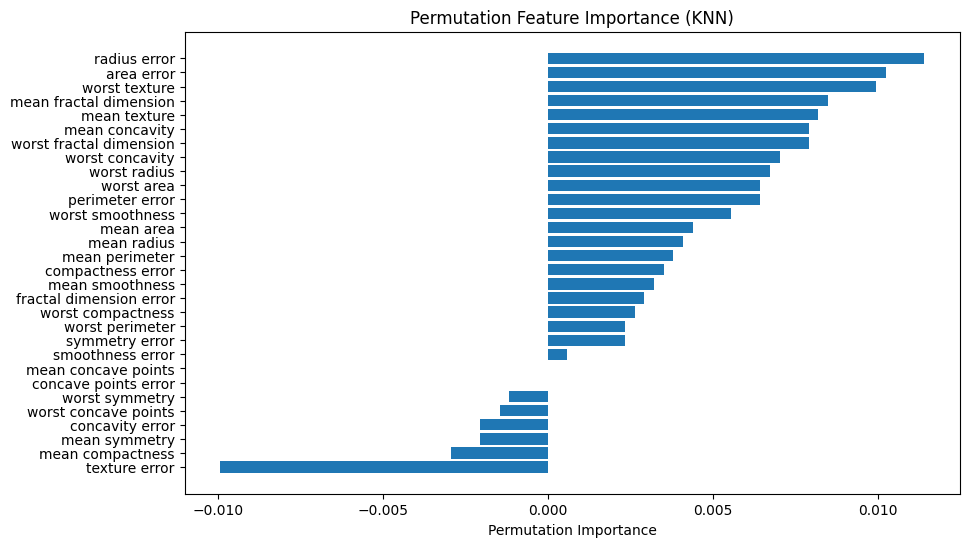

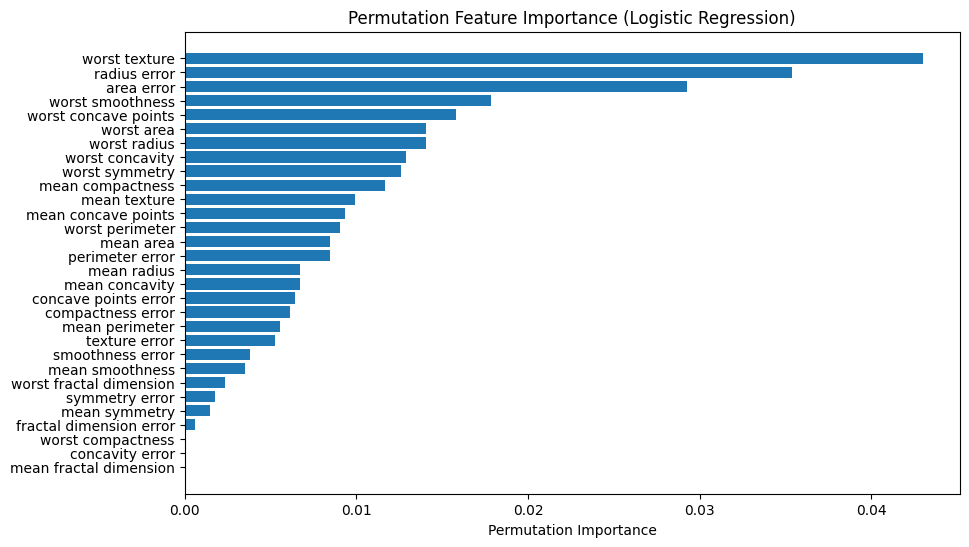

In [90]:
# Loop through models and plot permutation importance
for model_name, model in models.items():
    model.fit(X_train, y_train)
    perm_importance = permutation_importance(model, X_test, y_test, n_repeats=20, random_state=42)
    sorted_idx = perm_importance.importances_mean.argsort()

    plt.figure(figsize=(10,6))
    plt.barh(range(len(sorted_idx)), perm_importance.importances_mean[sorted_idx])
    plt.yticks(range(len(sorted_idx)), np.array(feature_names)[sorted_idx])
    plt.xlabel("Permutation Importance")
    plt.title(f"Permutation Feature Importance ({model_name})")
    plt.show()

In [91]:
# Dictionary of models
models = {
    "Random Forest": rf_best,
    "XGBoost": xgb_best,
    "Logistic Regression": lr,
    "KNN": knn
}

In [92]:
# Get feature names safely
feature_names = X.columns if hasattr(X, 'columns') else [f"Feature {i}" for i in range(X.shape[1])]


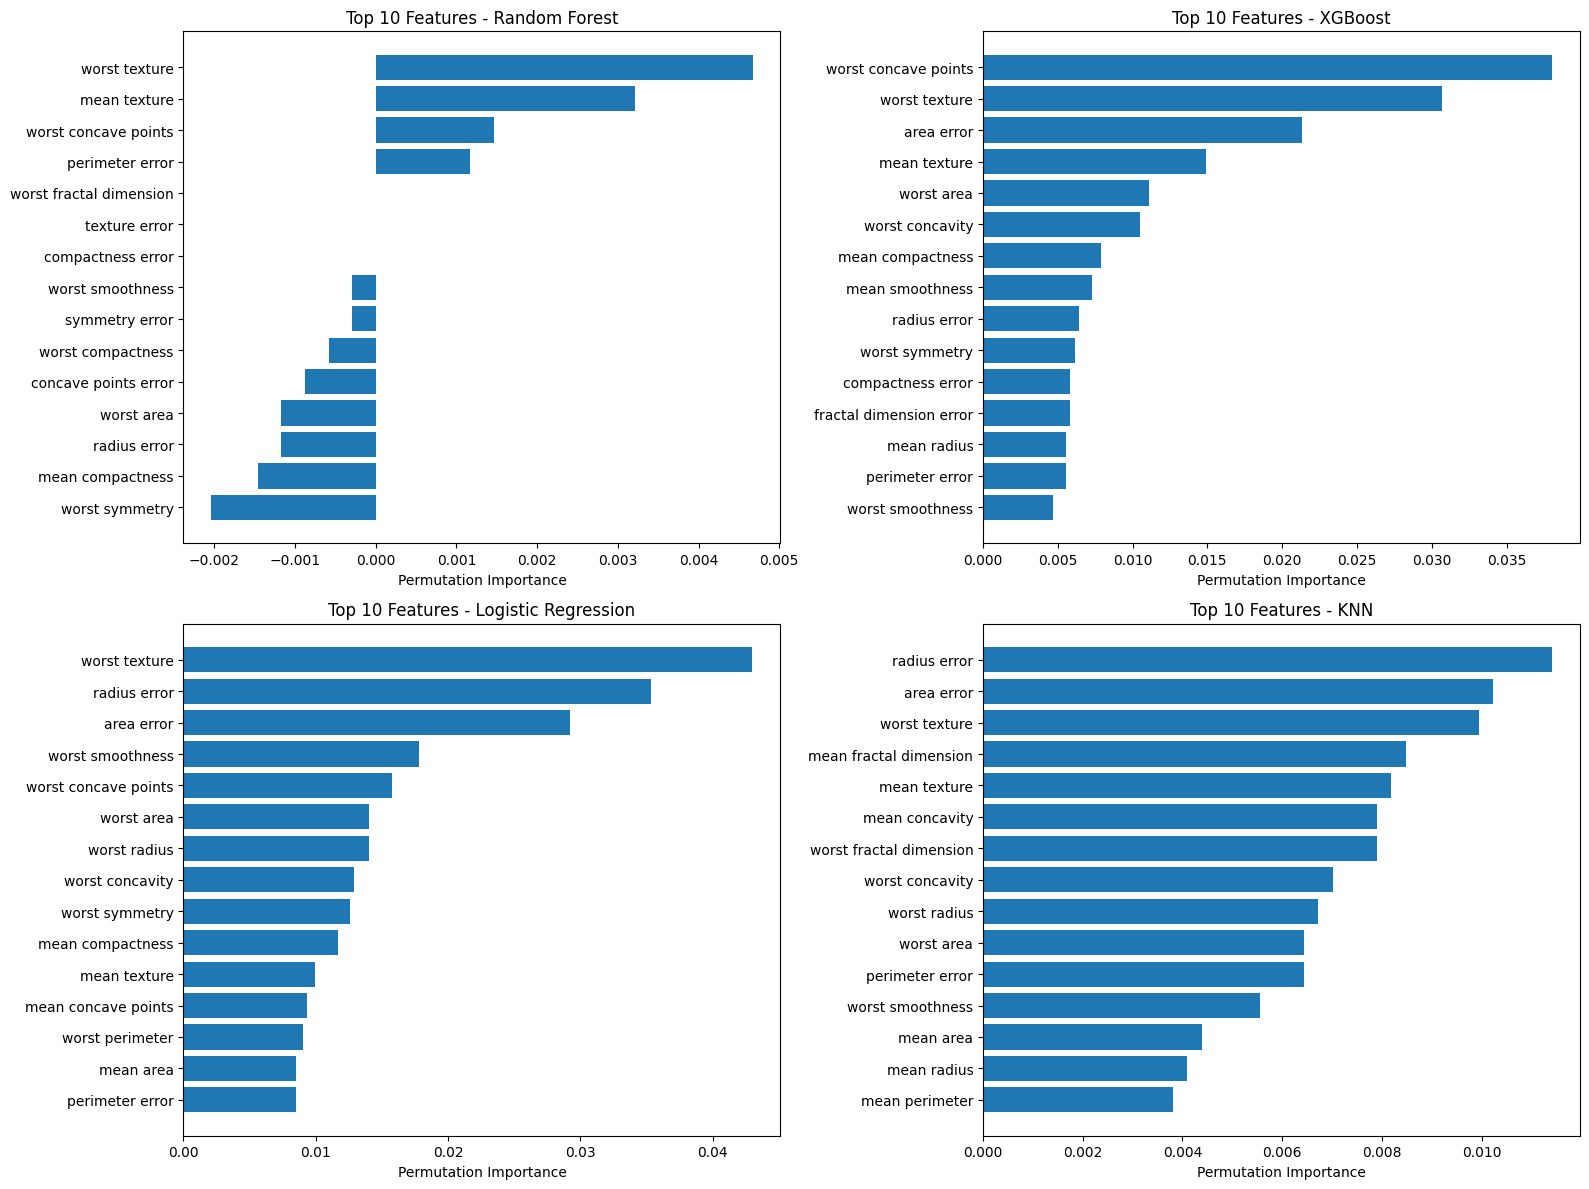

In [94]:
# Set up figure (2x2 layout)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

# Plot permutation importance for each model (top 10 features)
for idx, (model_name, model) in enumerate(models.items()):
    model.fit(X_train, y_train)
    perm_importance = permutation_importance(model, X_test, y_test, n_repeats=20, random_state=42)
    sorted_idx = perm_importance.importances_mean.argsort()[-15:]  # top 10 features
    
    axes[idx].barh(range(len(sorted_idx)), perm_importance.importances_mean[sorted_idx])
    axes[idx].set_yticks(range(len(sorted_idx)))
    axes[idx].set_yticklabels(np.array(feature_names)[sorted_idx])
    axes[idx].set_xlabel("Permutation Importance")
    axes[idx].set_title(f"Top 10 Features - {model_name}")

plt.tight_layout()
plt.show()

🟩 Green → Feature common to 2 or more models

🔵 Blue → Feature unique to that model's top 10 list

| **Rank** | **Random Forest**                            | **XGBoost**                                   | **Logistic Regression**                       | **KNN**                                     |
|----------|----------------------------------------------|-----------------------------------------------|-----------------------------------------------|---------------------------------------------|
| 1        | 🟩 worst texture                             | 🟩 worst concave points                        | 🟩 worst texture                               | 🔵 radius error                             |
| 2        | 🟩 mean texture                              | 🟩 worst texture                               | 🔵 radius error                                | 🔵 area error                               |
| 3        | 🟩 worst concave points                      | 🔵 area error                                 | 🟩 area error                                  | 🟩 worst texture                            |
| 4        | 🔵 perimeter error                           | 🟩 mean texture                               | 🔵 worst smoothness                            | 🔵 mean fractal dimension                   |
| 5        | 🔵 worst fractal dimension                   | 🔵 worst area                                 | 🟩 worst concave points                        | 🟩 mean texture                             |
| 6        | 🔵 texture error                             | 🟩 worst concavity                            | 🟩 worst area                                  | 🟩 mean concavity                           |
| 7        | 🔵 compactness error                         | 🔵 mean compactness                           | 🔵 worst smoothness                            | 🟩 worst fractal dimension                  |
| 8        | 🟩 worst smoothness                          | 🟩 mean smoothness                            | 🟩 worst radius                                | 🟩 worst concavity                          |
| 9        | 🔵 symmetry error                            | 🟩 radius error                               | 🟩 worst concavity                             | 🟩 worst radius                             |
| 10       | 🔵 worst compactness                         | 🔵 worst symmetry                             | 🟩 worst symmetry                              | 🟩 worst area                               |

**Insights :**

- Features like `worst texture`, `mean texture`, `worst concave points`, `worst area`, `worst concavity` are highly influential across multiple models.

- Features like `symmetry error`, `compactness error` are model-specific noise features, meaning only certain algorithms find them useful.